In [1]:
from utils_analysis import *
from utils_analysis_dynamic import *

from tqdm.notebook import tqdm

import numpy as np
import random as rnd
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

from copy import deepcopy

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator


import seaborn as sns




c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\Utente\OneDrive\Desktop\PB_ranking_experiment_and_simulation\PB_ranking_experiment_and_simulation\CODE ANALYSIS\utils_analysis_dynamic.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SEED2EVENTS[s]['time_seed']=range(1, len(SEED2EVENTS[s])+1)
c:\Users\Utente\OneDrive\Deskt

In [2]:
from sklearn.metrics import confusion_matrix

In [3]:
# plt.savefig=lambda *ar, **kw: print("SAVING WAS DISABLED")

In [4]:
plt.style.use("seaborn-whitegrid")

mpl.rcParams.update({
    # Font
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    
    # Axes and grid
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Lines and markers
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Default colormap for images
    "image.cmap": "Blues",

    # Default color cycle for plots
    "axes.prop_cycle": plt.cycler(
        color=[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
        ]
    ),

    # Figure
#     "figure.figsize": (6, 4),
#     "figure.dpi": 150,

    # Legend
    "legend.frameon": False,
})

mpl.rcParams["patch.force_edgecolor"] = True

In [5]:
MAP_HIGHLIGHT=lambda x: 1 if x in [0,1,2] else 0

# MAP_HIGHLIGHT=lambda x: 1 if x in [1,2] else 0

In [6]:
RESULTS=load_results(['RK2v3','RK2v4'])

RK2v3
RK2v4
Number of valid entries: 431


In [7]:
RESULTS

,player_id,round,topic,gender,age,stance_user,stance_user_topicwise,click_id,click_rank,highlight,...,news_source,time_positioning,time_taskexplaination,time_ranking,time_highlight,stance_text_error,user_avgerror,time_decision,user_avgtime,user_mintime
0,482910.0,1,2,1,4,1,0.0,21.0,2.0,3.0,...,wonkette.com,16.59,10.65,44.76,24.80,1.0,1.00,86.15,65.7775,50.66
1,218496.0,1,2,-1,4,1,1.0,23.0,0.0,3.0,...,edition.cnn.com,17.21,10.67,7.69,17.06,0.0,1.00,41.96,43.8225,24.19
2,804461.0,1,1,1,5,1,1.0,12.0,2.0,0.0,...,apnews.com,24.41,21.46,28.03,265.31,1.0,0.50,317.75,181.6425,72.24
3,583460.0,1,2,1,4,-1,0.0,28.0,8.0,3.0,...,thenationalpulse.com,16.78,13.29,17.39,12.77,1.0,1.50,46.94,46.5175,18.21
4,463139.0,1,2,-1,4,2,-2.0,25.0,8.0,2.0,...,newsnationnow.com,32.06,31.42,63.93,195.52,2.0,2.00,291.51,191.8025,138.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1719,373443.0,4,1,-1,1,-2,-2.0,12.0,9.0,0.0,...,apnews.com,5.68,12.72,46.25,102.41,0.0,0.50,154.34,121.2900,84.13
1720,483199.0,4,1,-1,3,-2,0.0,15.0,4.0,2.0,...,thehill.com,30.26,5.46,13.70,102.68,1.0,0.50,146.64,213.4100,146.64
1721,313112.0,4,4,-1,4,-1,-2.0,48.0,8.0,3.0,...,tfppwire.com,5.08,3.42,16.94,17.72,0.0,1.00,39.74,64.9500,39.74
1722,767819.0,4,3,-1,4,1,-1.0,30.0,6.0,2.0,...,dailykos.com,20.34,4.39,16.60,7.78,0.0,0.50,44.72,147.3875,44.72


In [8]:
RESULTS['active']=RESULTS['highlight'].map(MAP_HIGHLIGHT)
RESULTS['same_stance']=(RESULTS['stance_user_topicwise']==RESULTS['stance_text_true']).map(lambda x: 1 if x else 0)
RESULTS['same_partition']=(RESULTS['stance_user_topicwise'].map(np.sign)==RESULTS['stance_text_true'].map(np.sign)).map(lambda x: 1 if x else 0)

In [9]:
def get_vshape(res, x_axis_name):
    count=res.groupby(x_axis_name).count()['active']
    return (res.groupby(x_axis_name).sum()['active'].values/count).values
    
get_vshape(RESULTS, 'stance_user')

array([0.4672619 , 0.42827869, 0.30851064, 0.37804878, 0.5       ])

In [10]:
# def get_confirmatory(res):
#     count=res.groupby('stance_user_topicwise').count()['active']
#     return (res.groupby('stance_user_topicwise').sum()['same_stance']/count).values

# def get_confirmatory(res):
#     count=res.groupby('stance_user_topicwise').count()['active']
#     return (res.groupby('stance_user_topicwise').sum()['same_partition']/count).values

def stance2partition_click(res):
    cd= make_conf_dict('stance_user_topicwise','partition_text_true', res)

    cm=[list(cd[x].values()) for x in cd.keys()]
    cm=np.array(cm).T
    
    cm=cm.dot(np.diag(1/cm.sum(axis=0)))
    
    return cm

stance2partition_click(RESULTS)



array([[0.53818828, 0.42780749, 0.35121951, 0.18050542, 0.23606557],
       [0.29662522, 0.35026738, 0.3902439 , 0.32851986, 0.21311475],
       [0.1651865 , 0.22192513, 0.25853659, 0.49097473, 0.55081967]])

In [11]:
def ranking_distr(res):
    return [c for _, c in sorted(res['click_rank'].value_counts().to_dict().items(), key=lambda x: x[0])]

ranking_distr(RESULTS)

[289, 224, 187, 187, 169, 131, 119, 152, 137, 129]

In [12]:
def diagonal_mass(M):
    total = np.sum(M)
    return np.trace(M) / total if total > 0 else np.nan

def diagonal_mass_per_column(M):
    """
    Computes column-wise diagonal mass for a square confusion matrix M.
    Returns an array of length k.
    """
    col_sums = M.sum(axis=0)
    diag = np.diag(M)
    # Avoid division by zero
    T_col = np.divide(diag, col_sums, out=np.zeros_like(diag, dtype=float), where=col_sums!=0)
    return T_col

def Lift( T_obs, cat=5):
    return T_obs/(1/cat)

In [13]:

def normalized_confusion_matrix(df, col_x="stance_user", col_y="stance_user_topicwise"):
    labels = sorted(list(set(df[col_y]) | set(df[col_x])))
    cm = confusion_matrix(df[col_y], df[col_x], labels=labels)
    # Normalize by columns
    cm_colsum = cm.sum(axis=0, keepdims=True)
    cm_norm = cm / cm_colsum
    cm_norm = pd.DataFrame(cm_norm, index=labels, columns=labels)
    return cm_norm

In [14]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def power_law(x, a, b):
    return a * np.power(x, b)


    
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def power_law(x, a, b):
    return a * np.power(x, b)

def results_to_powerlaw_plot(results, plot=True, return_data=False, title=''):
    # count clicks per rank (same as before)
    r2c = {r: c for r, c in sorted(results['click_rank'].value_counts().to_dict().items(), key=lambda x: x[0])}

    rc = np.array([c for r, c in r2c.items()])
    ranks = np.array(list(r2c.keys()))

    # normalize to probabilities (like your bar plot)
    probs = rc / rc.sum()

    # avoid zeros for log
    mask = (ranks > 0) & (probs > 0)
    x = ranks[mask]
    y = probs[mask]

    # log-log transform
    log_x = np.log(x)
    log_y = np.log(y)

    # linear fit in log-log space
    b, log_a = np.polyfit(log_x, log_y, 1)
    a = np.exp(log_a)

    # std estimate (similar spirit to your beta std)
    residuals = log_y - (b * log_x + log_a)
    b_std = residuals.std()

    # reconstruct fitted distribution
    prob_fit = a * np.power(ranks, b)
    prob_fit = prob_fit / prob_fit.sum()

    if plot:
        plt.bar(range(len(rc)), probs)
        plt.plot(range(len(rc)), prob_fit, color='red')
        plt.title(f"{title}power-law: b={b:.3f} ± {b_std:.3f}")
        plt.grid()

    if return_data:
        return {'a':a, 'b':b, 'b_std':b_std}
    

def fit_powerlaw(
    RESULTS,
    fit_topicwise=False,
    title='',
    plot=True,
    return_data=True,
):
    
    if plot:
        plt.figure(figsize=(15,6))
        plt.subplot(2,4,(1,6))

    power_overall = results_to_powerlaw_plot(
        RESULTS, plot=plot, return_data=return_data, title='Overall: '
    )

    if fit_topicwise:
        power_topicwise = []
        for i in range(1, 4+1):
            t_res = RESULTS[RESULTS['topic'] == i]
            
            if plot:
                plt.subplot(2,4,2+i+2*(i//3))
            
            power_topicwise.append(
                results_to_powerlaw_plot(
                    t_res,
                    plot=plot,
                    return_data=return_data,
                    title=f'{N2TOPIC[i]}: '
                )
            )
        
        if plot:
            plt.tight_layout()

    if return_data:
        return power_overall['b'] #<---- don't need parameter a since it's normalize anyway

In [15]:
N_BOOTSTRAPPING=100

all_users=RESULTS['player_id'].unique()

conf_stance=[]
news_perc=[]

dd_to=[]
CC_to=[]
HH_to=[]

beta_o=[]
powr_o=[]
rank_o=[]

CC_h_to=[]

dd_go=[]
CC_go=[]
HH_go=[]

# dd_gt={t:[] for t in range(1,4+1)}
# CC_gt={t:[] for t in range(1,4+1)}
# HH_gt={t:[] for t in range(1,4+1)}

dd_tt={t:[] for t in range(1,4+1)}
CC_tt={t:[] for t in range(1,4+1)}
HH_tt={t:[] for t in range(1,4+1)}

beta_t={t:[] for t in range(1,4+1)}
powr_t={t:[] for t in range(1,4+1)}
rank_t={t:[] for t in range(1,4+1)}

CC_h_tt={t:[] for t in range(1,4+1)}

vs_go=[] #general stance and topic-aggregated
vs_to=[] #topic-wise stance and topic-aggregated
# vs_gt={t:[] for t in range(1,4+1)} #general stance topic-wise
vs_tt={t:[] for t in range(1,4+1)} #topic-wise stance and topic-aggregated

for i in tqdm(range(N_BOOTSTRAPPING)):
    ######################## make bootstrapped dataset
    i_users=np.random.choice(all_users, len(all_users))
    #---- build dataframe
    b_res_df=[]
    for user in i_users:
        b_res_df.append(RESULTS[RESULTS['player_id']==user])
    b_res_df=pd.concat(b_res_df)
    
    ####################### stance confusion matrix
    conf_stance.append(normalized_confusion_matrix(b_res_df).values)
    
    ####################### news perception
    news_perc.append(normalized_confusion_matrix(b_res_df, col_x='stance_text_true', col_y='stance_text_perc').values)
    
    
    ####################### extract d,C,H
    #---- overall stance
    _d,_C,_H=get_dch(b_res_df, x_name='stance_user', \
                     map_highlight=MAP_HIGHLIGHT, apply_droprule=False, apply_cutoff=False)
    dd_go.append(_d)
    CC_go.append(_C)
    HH_go.append(_H)
    #---- topicwise-stance
    _d,_C,_H=get_dch(b_res_df, x_name='stance_user_topicwise', \
                     map_highlight=MAP_HIGHLIGHT, apply_droprule=False, apply_cutoff=False)
    dd_to.append(_d)
    CC_to.append(_C)
    HH_to.append(_H)
    ####################### fit beta
    beta_o.append(fit_beta(b_res_df, plot=False))
    
    ####################### fit power low
    powr_o.append(fit_powerlaw(b_res_df, plot=False))

    ###################### fit rank distr
    rank_o.append(ranking_distr(b_res_df))
    
    ####################### clicking matrix partitionwise
    CC_h_to.append(stance2partition_click(b_res_df))
    
    ####################### extract v-shapes
    #---- overall stance
    _vs_go=get_vshape(b_res_df, 'stance_user')
    vs_go.append(_vs_go)
    #---- topicwise-stance
    _vs_to=get_vshape(b_res_df, 'stance_user_topicwise')
    vs_to.append(_vs_to)
    
    for topic in range(1,4+1):
        t_b_res_df=b_res_df[b_res_df['topic']==topic]
        
        _d,_C,_H=get_dch(t_b_res_df, x_name='stance_user_topicwise', \
                         map_highlight=MAP_HIGHLIGHT, apply_droprule=False, apply_cutoff=False)
        dd_tt[topic].append(_d)
        CC_tt[topic].append(_C)
        HH_tt[topic].append(_H)
        
        beta_t[topic].append(fit_beta(t_b_res_df, plot=False))
        powr_t[topic].append(fit_powerlaw(t_b_res_df, plot=False))
        rank_t[topic].append(ranking_distr(t_b_res_df))

        CC_h_tt[topic].append(stance2partition_click(t_b_res_df))
        
        _vs_tt=get_vshape(t_b_res_df, 'stance_user_topicwise')
        vs_tt[topic].append(_vs_tt)

conf_stance_avg=np.array(conf_stance).mean(axis=0)
conf_stance_std =np.array(conf_stance).std(axis=0)

news_perc_avg=np.array(news_perc).mean(axis=0)
news_perc_std =np.array(news_perc).std(axis=0)

dd_to_avg =np.array(dd_to).mean(axis=0)
dd_to_std =np.array(dd_to).std(axis=0)
CC_to_avg =np.array(CC_to).mean(axis=0)
CC_to_std =np.array(CC_to).std(axis=0)
HH_to_avg =np.array(HH_to).mean(axis=0)
HH_to_std =np.array(HH_to).std(axis=0)

beta_o_avg=np.array(beta_o).mean(axis=0)
beta_o_std=np.array(beta_o).std(axis=0)
powr_o_avg=np.array(powr_o).mean(axis=0)
powr_o_std=np.array(powr_o).std(axis=0)
rank_o_avg=np.array(rank_o).mean(axis=0)
rank_o_std=np.array(rank_o).std(axis=0)

CC_h_to_avg =np.array(CC_h_to).mean(axis=0)
CC_h_to_std =np.array(CC_h_to).std(axis=0)

dd_go_avg =np.array(dd_go).mean(axis=0)
dd_go_std =np.array(dd_go).std(axis=0)
CC_go_avg =np.array(CC_go).mean(axis=0)
CC_go_std =np.array(CC_go).std(axis=0)
HH_go_avg =np.array(HH_go).mean(axis=0)
HH_go_std =np.array(HH_go).std(axis=0)

vs_to_avg=np.array(vs_to).mean(axis=0)
vs_to_std=np.array(vs_to).std(axis=0)
vs_go_avg=np.array(vs_go).mean(axis=0)
vs_go_std=np.array(vs_go).std(axis=0)

dd_tt_avg={}
dd_tt_std={}
CC_tt_avg={}
CC_tt_std={}
HH_tt_avg={}
HH_tt_std={}

beta_t_avg={}
beta_t_std={}
powr_t_avg={}
powr_t_std={}
rank_t_avg={}
rank_t_std={}

CC_h_tt_avg={}
CC_h_tt_std={}

vs_tt_avg={}
vs_tt_std={}

for topic in range(1,4+1):
    dd_tt_avg[topic]=np.array(dd_tt[topic]).mean(axis=0)
    dd_tt_std[topic]=np.array(dd_tt[topic]).std(axis=0)
    CC_tt_avg[topic]=np.array(CC_tt[topic]).mean(axis=0)
    CC_tt_std[topic]=np.array(CC_tt[topic]).std(axis=0)
    HH_tt_avg[topic]=np.array(HH_tt[topic]).mean(axis=0)
    HH_tt_std[topic]=np.array(HH_tt[topic]).std(axis=0)
    
    beta_t_avg[topic]=np.array(beta_t[topic]).mean(axis=0)
    beta_t_std[topic]=np.array(beta_t[topic]).std(axis=0)
    powr_t_avg[topic]=np.array(powr_t[topic]).mean(axis=0)
    powr_t_std[topic]=np.array(powr_t[topic]).std(axis=0)
    rank_t_avg[topic]=np.array(rank_t[topic]).mean(axis=0)
    rank_t_std[topic]=np.array(rank_t[topic]).std(axis=0)
    
    CC_h_tt_avg[topic]=np.array(CC_h_tt[topic]).mean(axis=0)
    CC_h_tt_std[topic]=np.array(CC_h_tt[topic]).std(axis=0)
    
    vs_tt_avg[topic]=np.array(vs_tt[topic]).mean(axis=0)
    vs_tt_std[topic]=np.array(vs_tt[topic]).std(axis=0)

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:45: RuntimeWarning: divide by zero encountered in power
  prob_fit = a * np.power(ranks, b)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:46: RuntimeWarning: invalid value encountered in divide
  prob_fit = prob_fit / prob_fit.sum()
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:45: RuntimeWarning: divide by zero encountered in power
  prob_fit = a * np.power(ranks, b)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:46: RuntimeWarning: invalid value encountered in divide
  prob_fit = prob_fit / prob_fit.sum()
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:45: RuntimeWarning: divide by zero encountered in power
  prob_fit = a * np.power(ranks, b)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.py:46: RuntimeWarning: invalid value encountered in divide
  prob_fit = prob_fit / prob_fit.sum()
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\95471085.p

In [16]:
################## diagonal mass and lift
dm_to=[]
lift_to=[]

dm_c_to=[]
lift_c_to=[]
for cc in CC_to:
    dm_to.append(diagonal_mass(cc))
    lift_to.append(Lift(dm_to[-1]))
    dm_c_to.append(diagonal_mass_per_column(cc))
    lift_c_to.append(Lift(dm_c_to[-1]))
    
dm_to_avg=np.array(dm_to).mean(axis=0)
dm_to_std=np.array(dm_to).std(axis=0)
lift_to_avg=np.array(lift_to).mean(axis=0)
lift_to_std=np.array(lift_to).std(axis=0)

dm_c_to_avg=np.array(dm_c_to).mean(axis=0)
dm_c_to_std=np.array(dm_c_to).std(axis=0)
lift_c_to_avg=np.array(lift_c_to).mean(axis=0)
lift_c_to_std=np.array(lift_c_to).std(axis=0)


dm_tt={t: [] for t in range(1,4+1)}
lift_tt={t: [] for t in range(1,4+1)}

dm_c_tt={t: [] for t in range(1,4+1)}
lift_c_tt={t: [] for t in range(1,4+1)}

dm_tt_avg={t: [] for t in range(1,4+1)}
dm_tt_std={t: [] for t in range(1,4+1)}
lift_tt_avg={t: [] for t in range(1,4+1)}
lift_tt_std={t: [] for t in range(1,4+1)}

dm_c_tt_avg={t: [] for t in range(1,4+1)}
dm_c_tt_std={t: [] for t in range(1,4+1)}
lift_c_tt_avg={t: [] for t in range(1,4+1)}
lift_c_tt_std={t: [] for t in range(1,4+1)}

for t in range(1,4+1):
    for cc in CC_tt[t]:
        dm_tt[t].append(diagonal_mass(cc))
        lift_tt[t].append(Lift(dm_tt[t][-1]))
        
        dm_c_tt[t].append(diagonal_mass_per_column(cc))
        lift_c_tt[t].append(Lift(dm_c_tt[t][-1]))

    dm_tt_avg[t]=np.array(dm_tt[t]).mean(axis=0)
    dm_tt_std[t]=np.array(dm_tt[t]).std(axis=0)
    lift_tt_avg[t]=np.array(lift_tt[t]).mean(axis=0)
    lift_tt_std[t]=np.array(lift_tt[t]).std(axis=0)

    dm_c_tt_avg[t]=np.array(dm_c_tt[t]).mean(axis=0)
    dm_c_tt_std[t]=np.array(dm_c_tt[t]).std(axis=0)
    lift_c_tt_avg[t]=np.array(lift_c_tt[t]).mean(axis=0)
    lift_c_tt_std[t]=np.array(lift_c_tt[t]).std(axis=0)

# User stance distribution

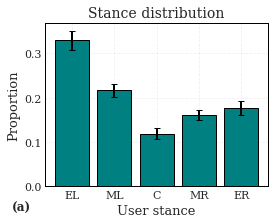

In [17]:
# plt.figure(figsize=(5,4.5))
# plt.bar(['EL','ML','C','MR','ER'],dd_go_avg, yerr=dd_to_std, capsize=3, color='teal')
# plt.title("General stance")
# plt.xlabel("User stance")
# plt.ylabel("Proportion")
# plt.show()
# Bottom-left panel label




plt.figure(figsize=(4,3))
plt.bar(['EL','ML','C','MR','ER'],dd_to_avg, yerr=dd_to_std, capsize=3, color='teal')
plt.title("Stance distribution")
plt.xlabel("User stance")
plt.ylabel("Proportion")

plt.figtext(
    0.01, -0.002, '(a)',
    fontsize=12,
    fontweight='bold',
    ha='left',
    va='bottom'
)

plt.savefig('user_stances.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/user_stances.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/user_stances.png', bbox_inches='tight')

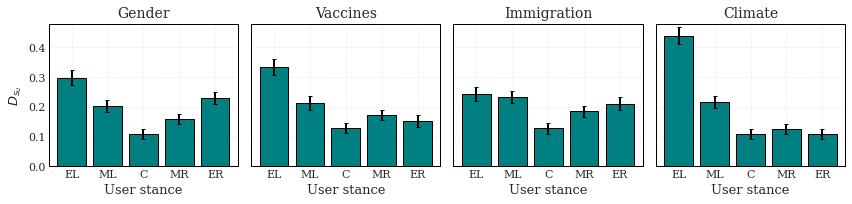

In [18]:
plt.figure(figsize=(12,3))
# plt.subplot(2,4,(1,6))
# plt.bar([-2,-1,0,1,2],dd_go_avg)
# plt.title("Aggregated")
# plt.bar(['EL','ML','C','MR','ER'],dd_to_avg, yerr=dd_to_std, capsize=3, color='teal')
# plt.xlabel("User stance")
# plt.ylabel("Proportion")
for pos, topic in zip([1,2,3,4],range(1,4+1)):
    plt.subplot(1,4,pos)
    plt.title(N2TOPIC[topic].capitalize())
    plt.bar(['EL','ML','C','MR','ER'], dd_tt_avg[topic], yerr=dd_tt_std[topic], capsize=2, color='teal')
#     if pos in [7,8]:
    plt.xlabel("User stance")
#     plt.ylabel("Proportion")
    plt.ylim(0,0.48)
    if topic==1:
        plt.ylabel("$D_{s_u}$")        
    else:
        plt.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.savefig("topicwise_user_stances.pdf", bbox_inches='tight')
# # plt.savefig('../Figures/topicwise_user_stances.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/topicwise_user_stances.png', bbox_inches='tight')

In [19]:

# Define a custom teal colormap (light → dark)
colors = ["#ffffff", "#64d8cb", "#004d40"]  # white → teal → dark teal
teal_cmap = LinearSegmentedColormap.from_list("custom_teal", colors)

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\3224307555.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im)


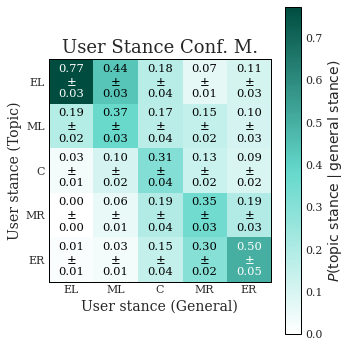

In [20]:
plt.figure(figsize=(5,5))     
im = plt.imshow(conf_stance_avg, cmap=teal_cmap)
plt.title("User Stance Conf. M.", fontsize=18)
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("User stance (General)", fontsize=14)
plt.ylabel("User stance (Topic)", fontsize=14)

# Create colorbar and set label
cbar = plt.colorbar(im)
cbar.set_label(r'$P(\mathrm{topic\ stance}\mid \mathrm{general\ stance})$', fontsize=14)

for i in range(conf_stance_std.shape[0]):
    for j in range(conf_stance_std.shape[1]):
        color = 'black' if conf_stance_avg[i, j] < 0.45 else 'white'
        plt.text(j, i, f'{conf_stance_avg[i, j]:.2f}\n$\pm$\n{conf_stance_std[i,j]:.2f}', 
                 ha='center', va='center', color=color, fontsize=11.5)

plt.grid(False)
plt.tight_layout()
plt.savefig("conf_stance.pdf", bbox_inches='tight')
# plt.savefig('../Figures/conf_stance.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/conf_stance.png', bbox_inches='tight')

# News perception

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2150345616.py:9: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  cbar = plt.colorbar(im)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2150345616.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im)


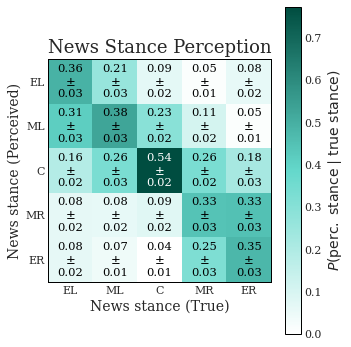

In [21]:
plt.figure(figsize=(5,5))     
plt.imshow(news_perc_avg, cmap=teal_cmap)
plt.title("News Stance Perception", fontsize=18)
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("News stance (True)", fontsize=14)
plt.ylabel("News stance (Perceived)", fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$P(\mathrm{perc.\ stance}\mid \mathrm{true\ stance})$', fontsize=14)

for i in range(news_perc_std.shape[0]):
    for j in range(news_perc_std.shape[1]):
        if news_perc_avg[i, j]<0.45:
            color='black'
        else:
            color='white'
        plt.text(j, i, f'{news_perc_avg[i, j]:.2f}\n$\pm$\n{news_perc_std[i,j]:.2f}', ha='center', va='center', color=color, fontsize=11.5)
plt.grid(False)
plt.tight_layout()
plt.savefig("news_perc.pdf", bbox_inches='tight')
# plt.savefig('../Figures/news_perc.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/news_perc.png', bbox_inches='tight')

# Ranking effect hypothesis

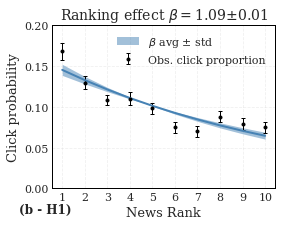

In [22]:
plt.figure(figsize=(4,3))
plt.errorbar(range(1,11), rank_o_avg/rank_o_avg.sum(), yerr=rank_o_std/rank_o_avg.sum(), 
             capsize=2, marker='o', color='black', linewidth=0, elinewidth=1, markersize=3, label='Obs. click proportion')
prob_ext_avg=np.array([beta_o_avg**(10-r) for r in range(10)])
prob_ext_avg=prob_ext_avg/prob_ext_avg.sum()

prob_ext_up=np.array([(beta_o_avg+beta_o_std)**(10-r) for r in range(10)])
prob_ext_up=prob_ext_up/prob_ext_up.sum()
prob_ext_low=np.array([(beta_o_avg-beta_o_std)**(10-r) for r in range(10)])
prob_ext_low=prob_ext_low/prob_ext_low.sum()

plt.fill_between(range(1,11), prob_ext_low, prob_ext_up, color="steelblue", alpha=0.5, label="$\\beta$ avg $\pm$ std", linewidth=0)

plt.plot(range(1,11), prob_ext_avg, color='steelblue')#, label="$\\beta$ avg")
plt.title(f"Ranking effect $\\beta=${beta_o_avg:.2f}$\pm${beta_o_std:.2f}")
plt.legend(loc='upper right')
plt.xlabel("News Rank")
plt.ylabel("Click probability")
plt.xticks(range(1,10+1), range(1,10+1));
plt.ylim(0,0.2)
plt.figtext(
    0.01, -0.002, '(b - H1)',
    fontsize=12,
    fontweight='bold',
    ha='left',
    va='bottom'
)
plt.savefig("beta_overall.pdf", bbox_inches='tight')
# # plt.savefig('../Figures/beta_overall.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/beta_overall.png', bbox_inches='tight')

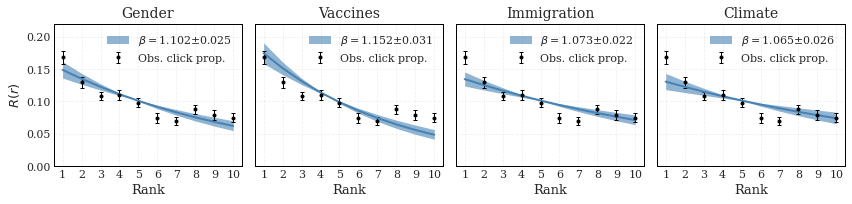

In [23]:
plt.figure(figsize=(12,3))
for t in range(1,4+1):
    plt.subplot(1,4,t)
    plt.errorbar(range(1,11), rank_o_avg/rank_o_avg.sum(), yerr=rank_o_std/rank_o_avg.sum(), 
             capsize=2, marker='o', color='black', linewidth=0, elinewidth=1, markersize=3, label='Obs. click prop.')
    prob_ext_avg=np.array([beta_t_avg[t]**(10-r) for r in range(10)])
    prob_ext_avg=prob_ext_avg/prob_ext_avg.sum()
    prob_ext_up=np.array([(beta_t_avg[t]+beta_t_std[t])**(10-r) for r in range(10)])
    prob_ext_up=prob_ext_up/prob_ext_up.sum()
    prob_ext_low=np.array([(beta_t_avg[t]-beta_t_std[t])**(10-r) for r in range(10)])
    prob_ext_low=prob_ext_low/prob_ext_low.sum()

    plt.fill_between(range(1,11), prob_ext_low, prob_ext_up, color="steelblue", alpha=0.6, label=f"$\\beta=${beta_t_avg[t]:.3f}$\pm${beta_t_std[t]:.3f}", linewidth=0)

    plt.plot(range(1,11), prob_ext_avg, color='steelblue')#, label='$\\beta$ avg')
    plt.title(f"{N2TOPIC[t].capitalize()}")
    plt.legend(loc='upper right')
    plt.ylim(0,0.22)
    plt.xticks(range(1,10+1), range(1,10+1));
    
    plt.xlabel("Rank")
    if t in [1]:
        plt.ylabel("$R(r)$")
    else:
        plt.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.savefig("topicwise_powr.pdf", bbox_inches='tight')
# plt.savefig('../Figures/topicwise_powr.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/topicwise_powr.png', bbox_inches='tight')

### Ranking effect hypothesis (Power low fit)

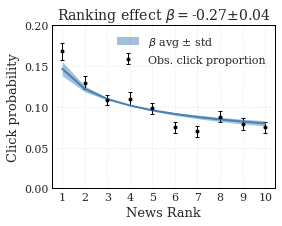

In [24]:
plt.figure(figsize=(4,3))
plt.errorbar(range(1,11), rank_o_avg/rank_o_avg.sum(), yerr=rank_o_std/rank_o_avg.sum(), 
             capsize=2, marker='o', color='black', linewidth=0, elinewidth=1, markersize=3, label='Obs. click proportion')
prob_ext_avg=np.array([r**(powr_o_avg) for r in range(1,1+10)])
prob_ext_avg=prob_ext_avg/prob_ext_avg.sum()

prob_ext_up=np.array([r**(powr_o_avg+powr_o_std) for r in range(1,1+10)])
prob_ext_up=prob_ext_up/prob_ext_up.sum()
prob_ext_low=np.array([r**(powr_o_avg-powr_o_std) for r in range(1,1+10)])
prob_ext_low=prob_ext_low/prob_ext_low.sum()

plt.fill_between(range(1,11), prob_ext_low, prob_ext_up, color="steelblue", alpha=0.5, label="$\\beta$ avg $\pm$ std", linewidth=0)

plt.plot(range(1,11), prob_ext_avg, color='steelblue')#, label="$\\beta$ avg")
plt.title(f"Ranking effect $\\beta=${powr_o_avg:.2f}$\pm${powr_o_std:.2f}")
plt.legend(loc='upper right')
plt.xlabel("News Rank")
plt.ylabel("Click probability")
plt.xticks(range(1,10+1), range(1,10+1));
plt.ylim(0,0.2)
plt.savefig("beta_overall.pdf", bbox_inches='tight')
# plt.savefig('../Figures/beta_overall.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/beta_overall.png', bbox_inches='tight')

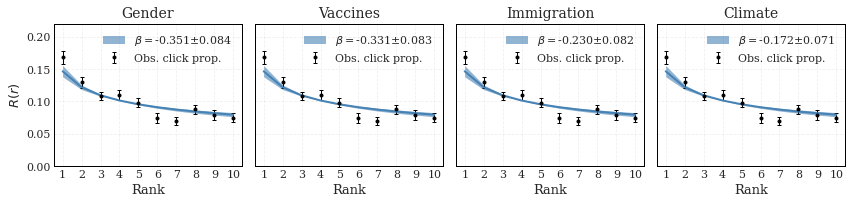

In [25]:
plt.figure(figsize=(12,3))
for t in range(1,4+1):
    plt.subplot(1,4,t)
    plt.errorbar(range(1,11), rank_o_avg/rank_o_avg.sum(), yerr=rank_o_std/rank_o_avg.sum(), 
             capsize=2, marker='o', color='black', linewidth=0, elinewidth=1, markersize=3, label='Obs. click prop.')
    prob_ext_avg=np.array([r**(powr_o_avg) for r in range(1,1+10)])
    prob_ext_avg=prob_ext_avg/prob_ext_avg.sum()

    prob_ext_up=np.array([r**(powr_o_avg+powr_o_std) for r in range(1,1+10)])
    prob_ext_up=prob_ext_up/prob_ext_up.sum()
    prob_ext_low=np.array([r**(powr_o_avg-powr_o_std) for r in range(1,1+10)])
    prob_ext_low=prob_ext_low/prob_ext_low.sum()

    plt.fill_between(range(1,11), prob_ext_low, prob_ext_up, color="steelblue", alpha=0.6, label=f"$\\beta=${powr_t_avg[t]:.3f}$\pm${powr_t_std[t]:.3f}", linewidth=0)

    plt.plot(range(1,11), prob_ext_avg, color='steelblue')#, label='$\\beta$ avg')
    plt.title(f"{N2TOPIC[t].capitalize()}")
    plt.legend(loc='upper right')
    plt.ylim(0,0.22)
    plt.xticks(range(1,10+1), range(1,10+1));
    
    plt.xlabel("Rank")
    if t in [1]:
        plt.ylabel("$R(r)$")
    else:
        plt.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.savefig("topicwise_powr.pdf", bbox_inches='tight')
# plt.savefig('../Figures/topicwise_powr.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/topicwise_powr.png', bbox_inches='tight')

In [26]:
prob_ext_avg=np.array([r**(powr_o_avg) for r in range(1,1+10)])

# Click matrix hypothesis

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\1630612735.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


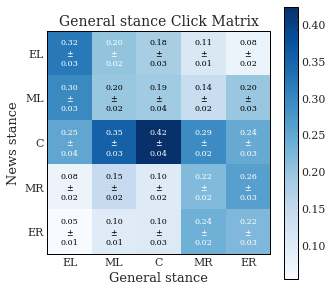

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\1630612735.py:26: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


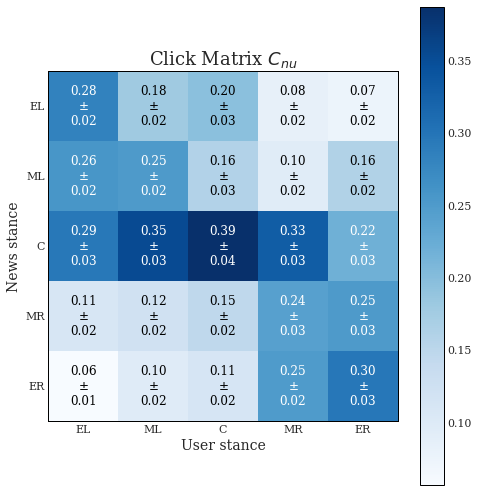

In [27]:
plt.figure(figsize=(5,5))
plt.imshow(CC_go_avg, cmap='Blues')
plt.title("General stance Click Matrix")
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("General stance")
plt.ylabel("News stance")
plt.colorbar()
for i in range(CC_go_std.shape[0]):
    for j in range(CC_go_std.shape[1]):
        if CC_go_avg[i, j]<0.2:
            color='black'
        else:
            color='white'
        plt.text(j, i, f'{CC_go_avg[i, j]:.2f}\n$\pm$\n{CC_go_std[i,j]:.2f}', ha='center', va='center', color=color, fontsize=8)
plt.grid(False)
plt.show()

plt.figure(figsize=(7,7))     
plt.imshow(CC_to_avg, cmap='Blues')
plt.title("Click Matrix $C_{nu}$", fontsize=18)
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("User stance", fontsize=14)
plt.ylabel("News stance", fontsize=14)
plt.colorbar()
for i in range(CC_to_std.shape[0]):
    for j in range(CC_to_std.shape[1]):
        if CC_to_avg[i, j]<0.2:
            color='black'
        else:
            color='white'
        plt.text(j, i, f'{CC_to_avg[i, j]:.2f}\n$\pm$\n{CC_to_std[i,j]:.2f}', ha='center', va='center', color=color, fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig("click_matrix.pdf", bbox_inches='tight')
# plt.savefig('../Figures/click_matrix.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/click_matrix.png', bbox_inches='tight')

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\3074658641.py:37: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im_list[-1], cax=cbar_ax)


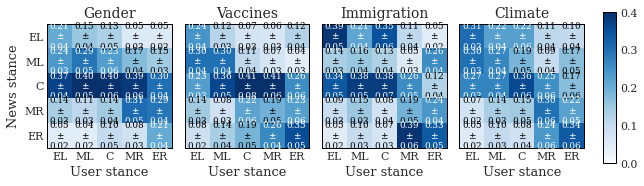

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(9, 3))

# Collect imshow objects for the shared colorbar
im_list = []

for topic in range(1, 4 + 1):
    ax = axes[topic - 1]
    im = ax.imshow(CC_tt_avg[topic], vmin=0, vmax=0.4)
    im_list.append(im)

    ax.set_title(f"{N2TOPIC[topic].capitalize()}")
    ax.set_xticks(range(5))
    ax.set_xticklabels(['EL', 'ML', 'C', 'MR', 'ER'])
    ax.set_yticks(range(5))
    ax.set_yticklabels(['EL', 'ML', 'C', 'MR', 'ER'])
    ax.set_xlabel("User stance")
    if topic == 1:
        ax.set_ylabel("News stance")
    else:
        ax.tick_params(axis='y', labelleft=False)


    for i in range(CC_tt_std[topic].shape[0]):
        for j in range(CC_tt_std[topic].shape[1]):
            color = 'black' if CC_tt_avg[topic][i, j] < 0.2 else 'white'
#             Uncomment this line if you want text labels
            ax.text(j, i, f'{CC_tt_avg[topic][i, j]:.2f}\n±\n{CC_tt_std[topic][i,j]:.2f}',
                    ha='center', va='center', color=color, fontsize=8.8)

    ax.grid(False)

# Adjust layout
fig.tight_layout(rect=[0, 0, 0.93, 1])  # leave space for colorbar on right

# Add ONE shared colorbar at the right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im_list[-1], cax=cbar_ax)

# Save
plt.savefig("topicwise_click_matrix.pdf", bbox_inches='tight')
# # plt.savefig("../Figures/topicwise_click_matrix.pdf", bbox_inches='tight')
# # plt.savefig("../Figures/png/topicwise_click_matrix.png", bbox_inches='tight')

# Lift

In [29]:
print(f"Overall \t{lift_to_avg:.4f}", f"+-{lift_to_std:.4f}")
for t in range(1,4+1):
    print(f"{N2TOPIC[t]:10} \t{lift_tt_avg[t]:.4f}", f"+-{lift_tt_std[t]:.4f}")

Overall 	1.4591 +-0.0665
gender     	1.4090 +-0.1027
vaccines   	1.5029 +-0.1240
immigration 	1.4462 +-0.1230
climate    	1.5686 +-0.1197


In [30]:
print(f"Overall   ",end='\t')
for s in range(5):
    print(f"{lift_c_to_avg[s]:.2f}+-{lift_c_to_std[s]:.2f}",end='\t')
print()
for t in range(1,4+1):
    print(f"{N2TOPIC[t]:10}", end='\t')
    for s in range(5):
        print(f"{lift_c_tt_avg[t][s]:.2f}+-{lift_c_tt_std[t][s]:.2f}", end='\t')
    print()

Overall   	1.41+-0.10	1.25+-0.11	1.94+-0.19	1.21+-0.16	1.48+-0.14	
gender    	1.04+-0.20	1.46+-0.25	1.98+-0.31	1.54+-0.26	1.03+-0.18	
vaccines  	1.21+-0.18	1.50+-0.22	2.07+-0.40	0.96+-0.25	1.77+-0.27	
immigration	1.94+-0.25	0.78+-0.18	1.88+-0.34	0.96+-0.25	1.67+-0.24	
climate   	1.53+-0.17	1.33+-0.22	1.80+-0.32	1.50+-0.30	1.68+-0.31	


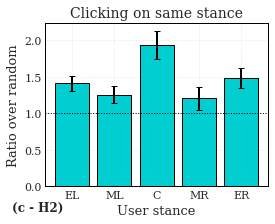

In [31]:
plt.figure(figsize=(4,3))
plt.title("Clicking on same stance")
plt.xlabel("User stance")
plt.ylabel("Ratio over random")
plt.axhline(1, color='k', linestyle=':', linewidth=1)
plt.bar(['EL','ML','C','MR','ER'], lift_c_to_avg, yerr=lift_c_to_std, color='darkturquoise', capsize=3)
# plt.ylim(1,2.3)
plt.figtext(
    0.01, -0.002, '(c - H2)',
    fontsize=12,
    fontweight='bold',
    ha='left',
    va='bottom'
)

plt.savefig("lift.pdf", bbox_inches='tight')
# # plt.savefig('../Figures/lift.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/lift.png', bbox_inches='tight')

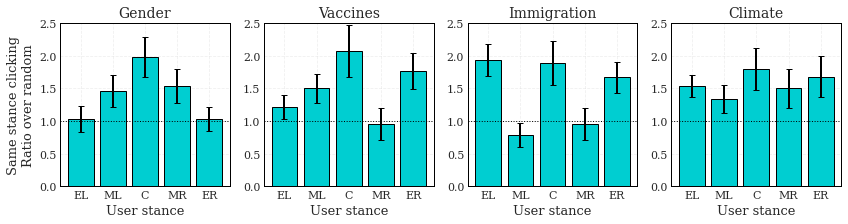

In [32]:
plt.figure(figsize=(14,3))
for t in range(1,4+1):
    plt.subplot(1,4,t)
    plt.title(f"{N2TOPIC[t].capitalize()}")
    plt.xlabel("User stance")
    if t==1:
        plt.ylabel("Same stance clicking\nRatio over random")
    plt.axhline(1, color='k', linestyle=':', linewidth=1)
    plt.bar(['EL','ML','C','MR','ER'], lift_c_tt_avg[t], yerr=lift_c_tt_std[t], color='darkturquoise', capsize=3)
    plt.ylim(0,2.5)
plt.savefig("topicwise_lift.pdf", bbox_inches='tight')
# plt.savefig('../Figures/topicwise_lift.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/topicwise_lift.png', bbox_inches='tight')

In [33]:
k = 5
n_perm = 1000

for t in range(4+1):
    if t==0:
        df=RESULTS
    else:
        df=RESULTS[RESULTS['topic']==t]


    # Function to compute confusion matrix from arrays
    def build_matrix(user_obs, post_obs, k):
        M = np.zeros((k, k), dtype=int)
        for u, p in zip(user_obs, post_obs):
            M[int(u+2), int(p+2)] += 1
        return M


    # Extract raw observations from DataFrame
    user_obs = df['stance_user_topicwise'].to_numpy()
    post_obs = df['stance_text_true'].to_numpy()

    # Observed diagonal mass
    M_obs = build_matrix(user_obs, post_obs, k)
    T_obs = diagonal_mass(M_obs)
    # per column
    T_obs_col = diagonal_mass_per_column(M_obs)

    # Permutation test at raw observation level
    T_null = []
    T_null_cols = np.zeros((n_perm, k))

    for _ in range(n_perm):
        permuted_users = np.random.permutation(user_obs)
        M_perm = build_matrix(permuted_users, post_obs, k)
        T_null.append(diagonal_mass(M_perm))
        
        # Permutation test for each column
        T_null_cols[i, :] = diagonal_mass_per_column(M_perm)

    T_null = np.array(T_null)

    # Empirical p-value
    p_value = np.mean(T_null >= T_obs)
    # Empirical p-value per column
    p_values_col = np.mean(T_null_cols >= T_obs_col, axis=0)
    
    if t!=0:
        print(f"{N2TOPIC[t]:10}", end='\t')
    else:
        print(f"Overall   ", end='\t')
    print(f"Permutation p-value for diagonality: {p_value}")
    for j in range(k):
        print(f"   Column {j}: p-value = {p_values_col[j]:.4f}")
    print()
    print()

Overall   	Permutation p-value for diagonality: 0.0
   Column 0: p-value = 0.0000
   Column 1: p-value = 0.0000
   Column 2: p-value = 0.0000
   Column 3: p-value = 0.0000
   Column 4: p-value = 0.0000


gender    	Permutation p-value for diagonality: 0.0
   Column 0: p-value = 0.0000
   Column 1: p-value = 0.0000
   Column 2: p-value = 0.0000
   Column 3: p-value = 0.0000
   Column 4: p-value = 0.0000


vaccines  	Permutation p-value for diagonality: 0.0
   Column 0: p-value = 0.0000
   Column 1: p-value = 0.0000
   Column 2: p-value = 0.0000
   Column 3: p-value = 0.0000
   Column 4: p-value = 0.0000


immigration	Permutation p-value for diagonality: 0.0
   Column 0: p-value = 0.0000
   Column 1: p-value = 0.0010
   Column 2: p-value = 0.0000
   Column 3: p-value = 0.0000
   Column 4: p-value = 0.0000


climate   	Permutation p-value for diagonality: 0.0
   Column 0: p-value = 0.0000
   Column 1: p-value = 0.0000
   Column 2: p-value = 0.0000
   Column 3: p-value = 0.0000
   Column 4

# Active engagement hypothesis

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2428338562.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


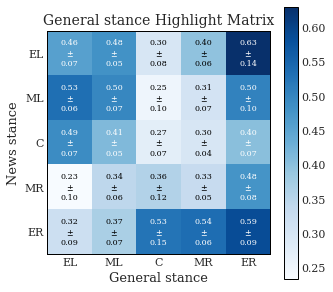

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2428338562.py:26: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


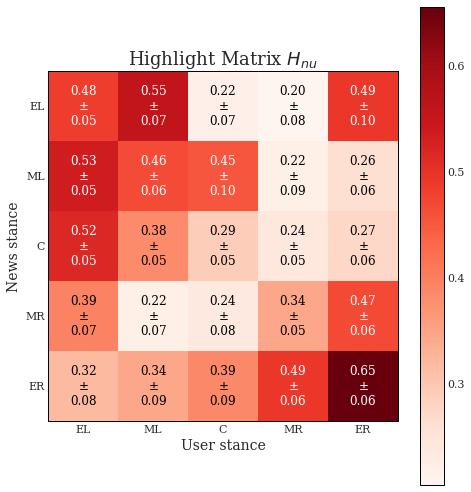

In [34]:
plt.figure(figsize=(5,5))
plt.imshow(HH_go_avg)
plt.title("General stance Highlight Matrix")
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("General stance")
plt.ylabel("News stance")
plt.colorbar()
for i in range(HH_go_std.shape[0]):
    for j in range(HH_go_std.shape[1]):
        if HH_go_avg[i, j]<0.4:
            color='black'
        else:
            color='white'
        plt.text(j, i, f'{HH_go_avg[i, j]:.2f}\n$\pm$\n{HH_go_std[i,j]:.2f}', ha='center', va='center', color=color, fontsize=8)
        plt.grid(False)
plt.show()

plt.figure(figsize=(7,7))     
plt.imshow(HH_to_avg, cmap='Reds')
plt.title("Highlight Matrix $H_{nu}$", fontsize=18)
plt.xticks(range(5), ['EL','ML','C','MR','ER'])
plt.yticks(range(5), ['EL','ML','C','MR','ER'])
plt.xlabel("User stance", fontsize=14)
plt.ylabel("News stance", fontsize=14)
plt.colorbar()
for i in range(HH_to_std.shape[0]):
    for j in range(HH_to_std.shape[1]):
        if HH_to_avg[i, j]<0.4:
            color='black'
        else:
            color='white'
        plt.text(j, i, f'{HH_to_avg[i, j]:.2f}\n$\pm$\n{HH_to_std[i,j]:.2f}', ha='center', va='center', color=color, fontsize=12)
        plt.grid(False)
plt.tight_layout()
plt.savefig('highlight_matrix.pdf', bbox_inches='tight')
# plt.savefig('../Figures/highlight_matrix.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/highlight_matrix.png', bbox_inches='tight')

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\4273267963.py:38: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(im_list[-1], cax=cbar_ax)


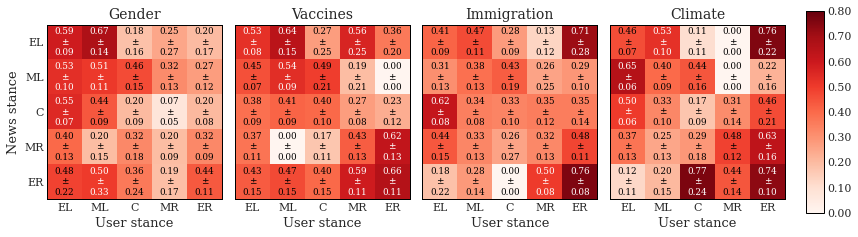

In [35]:

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

im_list = []

for topic in range(1, 4 + 1):
    ax = axes[topic - 1]
    im = ax.imshow(HH_tt_avg[topic], cmap='Reds', vmin=0, vmax=0.8)
    im_list.append(im)

    ax.set_title(f"{N2TOPIC[topic].capitalize()}")
    ax.set_xticks(range(5))
    ax.set_xticklabels(['EL', 'ML', 'C', 'MR', 'ER'])
    ax.set_yticks(range(5))
    ax.set_yticklabels(['EL', 'ML', 'C', 'MR', 'ER'])
    ax.set_xlabel("User stance")
    if topic == 1:
        ax.set_ylabel("News stance")
    else:
        ax.tick_params(axis='y', labelleft=False)


    for i in range(HH_tt_std[topic].shape[0]):
        for j in range(HH_tt_std[topic].shape[1]):
            color = 'black' if HH_tt_avg[topic][i, j] < 0.5 else 'white'
            ax.text(
                j, i,
                f'{HH_tt_avg[topic][i, j]:.2f}\n±\n{HH_tt_std[topic][i, j]:.2f}',
                ha='center', va='center', color=color, fontsize=8.8
            )

    ax.grid(False)

# Adjust layout to make room for shared colorbar
fig.tight_layout(rect=[0, 0, 0.93, 1])

# Add ONE shared colorbar at the right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im_list[-1], cax=cbar_ax)

# Format the colorbar tick labels to 2 decimal places
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Save to files
# fig.savefig('../figures/topicwise_highlight_matrix.pdf', bbox_inches='tight')
fig.savefig('topicwise_highlight_matrix.pdf', bbox_inches='tight')
# fig.savefig('../Figures/png/topicwise_highlight_matrix.png', bbox_inches='tight')

plt.show()

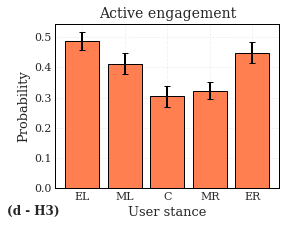

In [36]:
# plt.bar(['EL','ML','C','MR','ER'], vs_go_avg, yerr=vs_go_std, capsize=4)
# plt.title("General stance vs active engagement")
# plt.xlabel("General stance")
# plt.ylabel("Probability of active engagement")
# plt.show()

plt.figure(figsize=(4,3.3))
plt.bar(['EL','ML','C','MR','ER'], vs_to_avg, yerr=vs_to_std, capsize=3, color='coral')
plt.title("Active engagement")
plt.xlabel("User stance")
plt.ylabel("Probability")
plt.tight_layout()
plt.figtext(
    0.01, 0.06, '(d - H3)',
    fontsize=12,
    fontweight='bold',
    ha='left',
    va='bottom'
)
plt.savefig('v_shape.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/v_shape.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/v_shape.png', bbox_inches='tight')

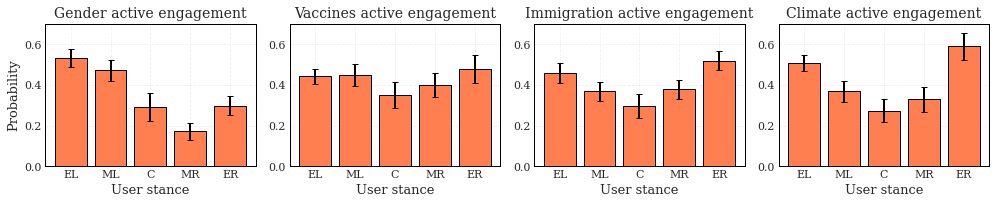

In [37]:
plt.figure(figsize=(14,3))
for topic in range(1,4+1):
    plt.subplot(1,4,topic)
    plt.bar(['EL','ML','C','MR','ER'], vs_tt_avg[topic], yerr=vs_tt_std[topic], capsize=3, color='coral')
    plt.title(f"{N2TOPIC[topic].capitalize()} active engagement")
#     if topic in [3,4]:
    plt.xlabel("User stance")
    if topic in [1]:
        plt.ylabel("Probability")# of\n active engagement")
    plt.ylim(0,0.7)
plt.tight_layout()
plt.savefig('topicwise_v_shape.pdf', bbox_inches='tight')
# plt.savefig('../Figures/topicwise_v_shape.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/topicwise_v_shape.png', bbox_inches='tight')

# V-shape and click lift topic-wise

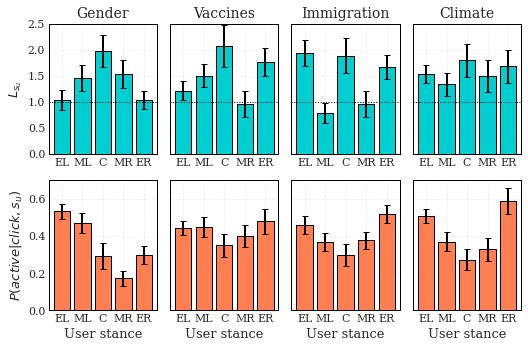

In [38]:
plt.figure(figsize=(7.5,5))
for t in range(1,4+1):
    plt.subplot(2,4,t)
    plt.title(f"{N2TOPIC[t].capitalize()}")
#     plt.xlabel("User stance")
    if t==1:
        plt.ylabel("$L_{s_u}$")
    else:
        plt.tick_params(axis='y', labelleft=False)

    plt.axhline(1, color='k', linestyle=':', linewidth=1)
    plt.bar(['EL','ML','C','MR','ER'], lift_c_tt_avg[t], yerr=lift_c_tt_std[t], color='darkturquoise', capsize=3)
    plt.ylim(0,2.5)

for topic in range(1,4+1):
    plt.subplot(2,4,4+topic)
    plt.bar(['EL','ML','C','MR','ER'], vs_tt_avg[topic], yerr=vs_tt_std[topic], capsize=3, color='coral')
#     plt.title(f"{N2TOPIC[topic].capitalize()}")
#     if topic in [3,4]:
    plt.xlabel("User stance")
    if topic in [1]:
        plt.ylabel("$P(active|click,s_u)$")# of\n active engagement")
    else:
        plt.tick_params(axis='y', labelleft=False)

    plt.ylim(0,0.7)
plt.tight_layout()
plt.savefig('topicwise_lift_and_vshape.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/topicwise_lift_and_vshape.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/topicwise_lift_and_vshape.png', bbox_inches='tight')

# Increase in extremism/polarization hypothesis

In [39]:
USER_ID_OCC=IE['user_id'].value_counts().to_dict()

tot_users=0
for u, occ in USER_ID_OCC.items():
    tot_users+=np.ceil(occ/4)
    
tot_users

1534.0

In [40]:
IE['seed'].value_counts()

seed
233    254
124    253
211    253
123    253
134    253
131    253
213    253
121    253
231    253
122    253
133    253
113    253
114    253
223    253
212    252
111    252
234    252
132    252
222    252
224    252
232    252
221    252
112    252
214    252
Name: count, dtype: int64

# Comparison with simulation

In [41]:
static_metrics={f'0*{t}':{'static_extremism_avg':'ph',
                          'static_extremism_std':'ph',
                          'static_polarization_avg':'ph',
                          'static_polarization_std':'ph',
                         } 
                for t in range(1,4+1)}

for topic in range(1,4+1):
    t_res=RESULTS[RESULTS['topic']==topic]
    
    ext=[]
    pol=[]
    for _ in range(100):
        sampled_df = t_res.sample(n=WINDOW_METRICS, replace=True)
        
        #----- calculate extremism
        ext.append(np.abs(sampled_df['stance_text_true']).mean())
        
        #----- calculate polariz
        l_=np.mean(sampled_df[sampled_df['partition_user']==-1]['stance_text_true'])
        r_=np.mean(sampled_df[sampled_df['partition_user']==1] ['stance_text_true'])
        pol.append(r_-l_)
        
    static_metrics[f'0*{topic}']['static_extremism_avg']=np.mean(ext)
    static_metrics[f'0*{topic}']['static_extremism_std']=np.std(ext)
    static_metrics[f'0*{topic}']['static_polarization_avg']=np.mean(pol)
    static_metrics[f'0*{topic}']['static_polarization_std']=np.std(pol)
    
static_metrics=pd.DataFrame(static_metrics).T

SM_DISPLAY=pd.DataFrame(index=static_metrics.index)
SM_DISPLAY['static_extremism']=static_metrics.round(2)['static_extremism_avg'].map(str)+'+-'+static_metrics.round(2)['static_extremism_std'].map(str)
SM_DISPLAY['static_polarization']=static_metrics.round(2)['static_polarization_avg'].map(str)+'+-'+static_metrics.round(2)['static_polarization_std'].map(str)

In [42]:
RESULTS_DISPLAY

,obs_extremism,sim_extremism,obs_polarization,sim_polarization
1*1,0.81+-0.05,0.72+-0.06,0.67+-0.33,0.6+-0.15
1*2,0.82+-0.04,0.86+-0.09,0.7+-0.07,0.79+-0.19
1*3,1.04+-0.09,1.07+-0.08,0.75+-0.16,1.07+-0.2
1*4,1.16+-0.07,1.06+-0.07,0.73+-0.06,1.02+-0.22
2*1,0.92+-0.06,0.8+-0.07,0.62+-0.16,0.86+-0.19
2*2,0.95+-0.1,1.02+-0.09,1.14+-0.21,1.36+-0.24
2*3,1.12+-0.08,1.12+-0.07,1.11+-0.12,1.35+-0.21
2*4,1.18+-0.07,1.1+-0.07,1.28+-0.09,1.32+-0.23


In [43]:
DYNAMIC_RESULTS

,obs_extremism_avg,obs_extremism_std,sim_extremism_avg,sim_extremism_std,obs_polarization_avg,obs_polarization_std,sim_polarization_avg,sim_polarization_std
1*1,0.810314,0.051059,0.715962,0.055909,0.665691,0.331827,0.599069,0.149808
1*2,0.820136,0.037553,0.863150,0.094794,0.704581,0.069190,0.786624,0.193783
1*3,1.043551,0.086973,1.065319,0.081303,0.751406,0.162785,1.069938,0.204420
1*4,1.155779,0.066032,1.059781,0.073921,0.726295,0.056310,1.017405,0.220136
2*1,0.915986,0.057820,0.803717,0.070435,0.622692,0.164135,0.861612,0.193215
2*2,0.946128,0.102707,1.021823,0.093599,1.135140,0.209643,1.358102,0.238401
2*3,1.115352,0.079185,1.122486,0.072415,1.114240,0.119235,1.347940,0.208438
2*4,1.180135,0.066151,1.096192,0.066483,1.278485,0.089691,1.319478,0.226126


### Mann-whitney E2 param1 vs E2 param2

See stat_test_EvE_blockwise.ipynb for *extension* of this test for the time-dependent accounting approach

NB for that test, 200 is the maximum sample size tested for the lists in the MW test. 
Here is 600 as it aggregates all same-topic x same-parametrization experimental repetitions together

At run level

In [44]:
PT2EXTS={p:{t:[]for t in range(1,4+1)} for p in [1,2]}
PT2POLS={p:{t:[]for t in range(1,4+1)} for p in [1,2]}

for s in SEEDS:
    p=int(str(s)[0])
    t=int(str(s)[2])
    PT2EXTS[p][t].append(SEED2EXTREMISM[s])
    PT2POLS[p][t].append(SEED2POLARIZATION[s])

In [45]:
EXT_MW={}
POL_MW={}
for t in range(1,4+1):
    stat, p_value = mannwhitneyu(PT2EXTS[1][t], PT2EXTS[2][t])#, alternative='two-sided', method='exact')
    EXT_MW[t]=p_value
    stat, p_value = mannwhitneyu(PT2POLS[1][t], PT2POLS[2][t])#, alternative='two-sided', method='exact')
    POL_MW[t]=p_value


In [46]:
EXT_MW

{1: 0.2, 2: 0.1, 3: 0.7, 4: 0.7}

In [47]:
POL_MW

{1: 0.7, 2: 0.1, 3: 0.1, 4: 0.1}

At click level

In [48]:
EXT_MW={}
POL_MW={}
for t in range(1,4+1):
    ev_1=P2EV[1][P2EV[1]['seed'].map(lambda x: x[2]==str(t))]['news_stance'].tolist()
    ev_2=P2EV[2][P2EV[2]['seed'].map(lambda x: x[2]==str(t))]['news_stance'].tolist()
    
    

    stat, p_value = mannwhitneyu(np.abs(ev_1), 
                                 np.abs(ev_2), 
                                 alternative='less')#, method='exact')
    EXT_MW[t]=p_value

    ev_1=deepcopy(P2EV[1][P2EV[1]['seed'].map(lambda x: str(x)[2]==str(t))])
    ev_2=deepcopy(P2EV[2][P2EV[2]['seed'].map(lambda x: str(x)[2]==str(t))])
    
    ################### polarization user-wise
    ev_1_left=ev_1[ev_1['user_partition']==-1]
    ev_1_right=ev_1[ev_1['user_partition']==1]
    ev_2_left=ev_2[ev_2['user_partition']==-1]
    ev_2_right=ev_2[ev_2['user_partition']==1]
    
    ev_1_left_avg=ev_1_left['news_stance'].mean()
    ev_1_right_avg=ev_1_right['news_stance'].mean()
    ev_2_left_avg=ev_2_left['news_stance'].mean()
    ev_2_right_avg=ev_2_right['news_stance'].mean()
    
    ev_1=ev_1_right['news_stance'].values-ev_1_left_avg 
    ev_1=np.append(ev_1, - (ev_1_left['news_stance'].values-ev_1_right_avg))
    ev_2=ev_2_right['news_stance'].values-ev_2_left_avg 
    ev_2=np.append(ev_2, - (ev_2_left['news_stance'].values-ev_2_right_avg))
        
    stat, p_value = mannwhitneyu(ev_1, 
                                 ev_2, 
                                 alternative='less')#, method='exact')
    

    POL_MW[t]=p_value

In [49]:
EXT_MW

{1: 0.00833804707702211,
 2: 0.0010623511279224693,
 3: 0.04382373968593866,
 4: 0.3519756463713607}

In [50]:
POL_MW

{1: 0.9684210973757291,
 2: 5.079845860250936e-28,
 3: 9.452086802177294e-09,
 4: 3.846894275028124e-13}

In [51]:
import matplotlib.pyplot as plt

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\247391614.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\247391614.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\247391614.py:80: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\247391614.py:105: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


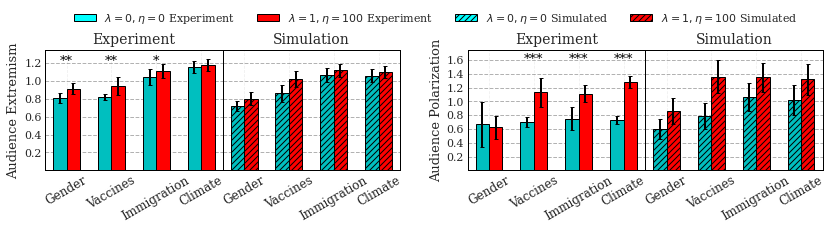

In [79]:
YLIM_FIG_2=(0,1.75)

# --- function to add significance markers ---
def add_significance(ax, x1, x2, y, h, significance_text):
    """Draws a significance line with stars between two bars."""
#     ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='k')
    ax.text((x1 + x2) * 0.5, y + h, significance_text,
            ha='center', va='bottom', color='k', fontsize=13)

plt.figure(figsize=(12, 3))

# === SUBPLOT 1 ===
plt.subplot(1,4,1)
plt.title("Experiment")

x = np.array(range(1, 5))
width = 0.3

plt.bar(x - 0.15, DYNAMIC_RESULTS.iloc[:4]['obs_extremism_avg'],
        yerr=DYNAMIC_RESULTS.iloc[:4]['obs_extremism_std'], width=width, color='c', label='1 obs', capsize=2)
plt.bar(x + 0.15, DYNAMIC_RESULTS.iloc[4:]['obs_extremism_avg'],
        yerr=DYNAMIC_RESULTS.iloc[4:]['obs_extremism_std'], width=width, color='r', label='2 obs', capsize=2)

plt.ylim(0, 1.35)
plt.xticks(range(1, 5), [N2TOPIC[t].capitalize() for t in range(1, 5)], fontsize=12, rotation=30)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)
labels = ["" if val == 0 else f"{val:.1f}" for val in ax.get_yticks()]
ax.set_yticklabels(labels)

significance_labels=['**','**','*','']

# --- Add significance markers ---
for i, sig in enumerate(significance_labels):
    y_max = max(DYNAMIC_RESULTS.iloc[i]['obs_extremism_avg'],
                DYNAMIC_RESULTS.iloc[i+4]['obs_extremism_avg'])
    add_significance(ax, x[i]-0.15, x[i]+0.15, 1.15, 0, sig)


# === SUBPLOT 2 ===
plt.subplot(1,4,2)
plt.title("Simulation")

plt.bar(x - 0.15, DYNAMIC_RESULTS.iloc[:4]['sim_extremism_avg'],
        yerr=DYNAMIC_RESULTS.iloc[:4]['sim_extremism_std'], width=width, color='c', label='1 sim', hatch='////', capsize=2)
plt.bar(x + 0.15, DYNAMIC_RESULTS.iloc[4:]['sim_extremism_avg'],
        yerr=DYNAMIC_RESULTS.iloc[4:]['sim_extremism_std'], width=width, color='r', label='2 sim', hatch='////', capsize=2)

plt.ylim(0, 1.35)
plt.xticks(range(1, 5), [N2TOPIC[t].capitalize() for t in range(1, 5)], fontsize=12, rotation=30)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)
labels = ["" if val == 0 else f"{val:.1f}" for val in ax.get_yticks()]
ax.set_yticklabels(labels)

# # --- Add significance markers --- # NO SIGNIFICANCE FOR SIMULATION?
# for i, sig in enumerate(significance_labels):
#     y_max = max(DYNAMIC_RESULTS.iloc[i]['sim_extremism_avg'],
#                 DYNAMIC_RESULTS.iloc[i+4]['sim_extremism_avg'])
#     add_significance(ax, x[i]-0.15, x[i]+0.15, y_max + 0.05, 0.03, sig)


# === SUBPLOT 3 ===
plt.subplot(1,4,3)
plt.title("Experiment")

plt.bar(x - 0.15, DYNAMIC_RESULTS.iloc[:4]['obs_polarization_avg'],
        yerr=DYNAMIC_RESULTS.iloc[:4]['obs_polarization_std'], width=width, color='c', label='1 obs', capsize=2)
plt.bar(x + 0.15, DYNAMIC_RESULTS.iloc[4:]['obs_polarization_avg'],
        yerr=DYNAMIC_RESULTS.iloc[4:]['obs_polarization_std'], width=width, color='r', label='2 obs', capsize=2)

plt.ylim(YLIM_FIG_2[0], YLIM_FIG_2[1])
plt.xticks(range(1, 5), [N2TOPIC[t].capitalize() for t in range(1, 5)], fontsize=12, rotation=30)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)
labels = ["" if val == 0 else f"{val:.1f}" for val in ax.get_yticks()]
ax.set_yticklabels(labels)

significance_labels=['','***','***','***']
# --- Add significance markers ---
for i, sig in enumerate(significance_labels):
    y_max = max(DYNAMIC_RESULTS.iloc[i]['obs_polarization_avg'],
                DYNAMIC_RESULTS.iloc[i+4]['obs_polarization_avg'])
    add_significance(ax, x[i]-0.15, x[i]+0.15, 1.52, 0, sig)


# === SUBPLOT 4 ===
plt.subplot(1,4,4)
plt.title("Simulation")

plt.bar(x - 0.15, DYNAMIC_RESULTS.iloc[:4]['sim_polarization_avg'],
        yerr=DYNAMIC_RESULTS.iloc[:4]['sim_polarization_std'], width=width, color='c', label='1 sim', hatch='////', capsize=2)
plt.bar(x + 0.15, DYNAMIC_RESULTS.iloc[4:]['sim_polarization_avg'],
        yerr=DYNAMIC_RESULTS.iloc[4:]['sim_polarization_std'], width=width, color='r', label='2 sim', hatch='////', capsize=2)

plt.ylim(YLIM_FIG_2[0], YLIM_FIG_2[1])
plt.xticks(range(1, 5), [N2TOPIC[t].capitalize() for t in range(1, 5)], fontsize=12, rotation=30)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)
labels = ["" if val == 0 else f"{val:.1f}" for val in ax.get_yticks()]
ax.set_yticklabels(labels)

# # --- Add significance markers ---
# for i, sig in enumerate(significance_labels):
#     y_max = max(DYNAMIC_RESULTS.iloc[i]['sim_polarization_avg'],
#                 DYNAMIC_RESULTS.iloc[i+4]['sim_polarization_avg'])
#     add_significance(ax, x[i]-0.15, x[i]+0.15, y_max + 0.05, 0.03, sig)

# === Layout and legend ===
plt.tight_layout()
plt.subplots_adjust(wspace=0.19, hspace=0)
axes = [plt.subplot(1,4,i) for i in range(1,5)]

# collapse pairs
pos1, pos2 = axes[0].get_position(), axes[1].get_position()
axes[1].set_position([pos1.x1, pos2.y0, pos2.width, pos2.height])
pos3, pos4 = axes[2].get_position(), axes[3].get_position()
axes[3].set_position([pos3.x1, pos4.y0, pos4.width, pos4.height])

# Legend
plt.subplot(1,4,1)
legend_patches = [
    mpatches.Patch(facecolor="cyan", label="$\\lambda=0, \\eta=0$ Experiment"),
    mpatches.Patch(facecolor="red",  label="$\\lambda=1, \\eta=100$ Experiment"),
    mpatches.Patch(facecolor="cyan", hatch="////",  label="$\\lambda=0, \\eta=0$ Simulated"),
    mpatches.Patch(facecolor="red", hatch="////", label="$\\lambda=1, \\eta=100$ Simulated"),
]
plt.legend(handles=legend_patches, loc="upper center", ncol=4,
           bbox_to_anchor=(2.2, 1.4), frameon=False)

plt.subplot(1,4,1)
plt.ylabel("Audience Extremism")
plt.subplot(1,4,3)
plt.ylabel("Audience Polarization")

axes[1].tick_params(labelleft=False)
axes[3].tick_params(labelleft=False)

plt.savefig('metrics_experiment_row.pdf', bbox_inches='tight')
plt.show()


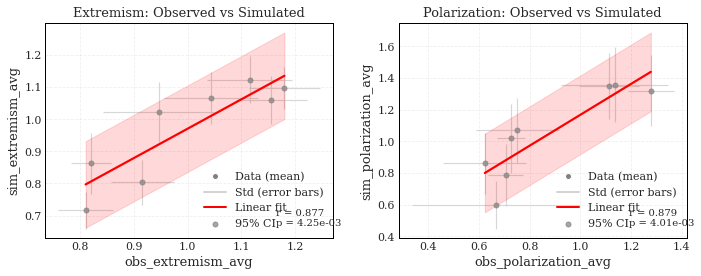

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# =========================================================
# Extract data
# =========================================================

# Extremism
obs_ext = DYNAMIC_RESULTS['obs_extremism_avg'].values
sim_ext = DYNAMIC_RESULTS['sim_extremism_avg'].values

obs_ext_std = DYNAMIC_RESULTS['obs_extremism_std'].values
sim_ext_std = DYNAMIC_RESULTS['sim_extremism_std'].values

# Polarization
obs_pol = DYNAMIC_RESULTS['obs_polarization_avg'].values
sim_pol = DYNAMIC_RESULTS['sim_polarization_avg'].values

obs_pol_std = DYNAMIC_RESULTS['obs_polarization_std'].values
sim_pol_std = DYNAMIC_RESULTS['sim_polarization_std'].values

# =========================================================
# Correlations
# =========================================================

r_ext, p_ext = pearsonr(obs_ext, sim_ext)
r_pol, p_pol = pearsonr(obs_pol, sim_pol)

# =========================================================
# Plot
# =========================================================

# plt.style.use('ggplot')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# =========================================================
# LEFT: Extremism
# =========================================================

ax = axes[0]

# Scatter
ax.scatter(obs_ext, sim_ext,
           color='gray', alpha=0.7, s=25, zorder=3)

# Error bars
ax.errorbar(obs_ext, sim_ext,
            xerr=obs_ext_std,
            yerr=sim_ext_std,
            fmt='none',
            ecolor='lightgray',
            elinewidth=1.2,
            capsize=0,
            alpha=0.9,
            zorder=1)

# Linear fit
coef = np.polyfit(obs_ext, sim_ext, 1)
poly1d_fn = np.poly1d(coef)

x_fit = np.linspace(obs_ext.min(), obs_ext.max(), 100)
y_fit = poly1d_fn(x_fit)

ax.plot(x_fit, y_fit,
        color='red',
        linewidth=2.2,
        label='Linear fit',
        zorder=4)

# 95% CI
y_pred = poly1d_fn(obs_ext)
residuals = sim_ext - y_pred
std_err = np.std(residuals)

ci = 1.96 * std_err

ax.fill_between(x_fit,
                poly1d_fn(x_fit) - ci,
                poly1d_fn(x_fit) + ci,
                color='red',
                alpha=0.15,
                label='95% CI',
                zorder=2)

# Labels
ax.set_title('Extremism: Observed vs Simulated', fontsize=13)
ax.set_xlabel('obs_extremism_avg')
ax.set_ylabel('sim_extremism_avg')

# Correlation text
ax.text(0.80, 0.05,
        f'r = {r_ext:.3f}\np = {p_ext:.2e}',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=10)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray', markersize=6,
           label='Data (mean)'),
    Line2D([0], [0], color='lightgray', lw=2,
           label='Std (error bars)'),
    Line2D([0], [0], color='red', lw=2,
           label='Linear fit')
]

ax.legend(handles=legend_elements + [ax.collections[0]],
          labels=['Data (mean)', 'Std (error bars)',
                  'Linear fit', '95% CI'],
          loc='lower right',
          frameon=False)

# =========================================================
# RIGHT: Polarization
# =========================================================

ax = axes[1]

# Scatter
ax.scatter(obs_pol, sim_pol,
           color='gray', alpha=0.7, s=25, zorder=3)

# Error bars
ax.errorbar(obs_pol, sim_pol,
            xerr=obs_pol_std,
            yerr=sim_pol_std,
            fmt='none',
            ecolor='lightgray',
            elinewidth=1.2,
            capsize=0,
            alpha=0.9,
            zorder=1)

# Linear fit
coef = np.polyfit(obs_pol, sim_pol, 1)
poly1d_fn = np.poly1d(coef)

x_fit = np.linspace(obs_pol.min(), obs_pol.max(), 100)

ax.plot(x_fit, poly1d_fn(x_fit),
        color='red',
        linewidth=2.2,
        zorder=4)

# 95% CI
y_pred = poly1d_fn(obs_pol)
residuals = sim_pol - y_pred
std_err = np.std(residuals)

ci = 1.96 * std_err

ax.fill_between(x_fit,
                poly1d_fn(x_fit) - ci,
                poly1d_fn(x_fit) + ci,
                color='red',
                alpha=0.15,
                zorder=2)

# Labels
ax.set_title('Polarization: Observed vs Simulated', fontsize=13)
ax.set_xlabel('obs_polarization_avg')
ax.set_ylabel('sim_polarization_avg')

# Correlation text
ax.text(0.80, 0.05,
        f'r = {r_pol:.3f}\np = {p_pol:.2e}',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=10)

# Legend
ax.legend(handles=legend_elements + [ax.collections[0]],
          labels=['Data (mean)', 'Std (error bars)',
                  'Linear fit', '95% CI'],
          loc='lower right',
          frameon=False)

# =========================================================
# Final layout
# =========================================================

plt.tight_layout()
plt.show()

In [54]:
def stat_test(list_1, list_2, title_prefix='', colors=('c','r'), hatches=('',''), MW=True,
              possible_values=[0,1,2], possible_values_names=['C','M','E'], width_reduction=1):
    cc_1=click_list_to_count(list_1)
    cc_2=click_list_to_count(list_2)
    
    cc_1=[cc_1[v] for v in possible_values]
    cc_2=[cc_2[v] for v in possible_values]
    
    cc_1_avg, cc_1_std=boostrap_click_list(list_1)
    cc_2_avg, cc_2_std=boostrap_click_list(list_2)
    table=np.array([
        cc_1,
        cc_2,
    ]
    )
    
        
    chi2, p, dof, expected = chi2_contingency(table)
    residuals = (table - expected) / np.sqrt(expected)

    if MW:
        stat, p = mannwhitneyu(list_2,
                               list_1,
                               alternative='greater')
#                                alternative='two-sided')#, method='exact')
    
    plt.bar(np.array(possible_values)-0.2/width_reduction, np.array(cc_1)/sum(cc_1), #cc_1_avg/cc_1_avg.sum(), yerr=cc_1_std/cc_1_avg.sum(), 
            color=colors[0], capsize=3, width=0.4/width_reduction, hatch=hatches[0])#, label='$\eta=0, \lambda=0$')
    plt.bar(np.array(possible_values)+0.2/width_reduction, np.array(cc_2)/sum(cc_2), #cc_2_avg/cc_2_avg.sum(), yerr=cc_2_std/cc_2_avg.sum(), 
            color=colors[1], capsize=3, width=0.4/width_reduction, hatch=hatches[1])#, label='$\eta=100, \lambda=1$')
    plt.title(title_prefix+f" p-value={p:.3f}")
    plt.xticks(possible_values, possible_values_names)
    plt.ylim(0,0.55)
    plt.xlabel("News stance")
    print(np.array(cc_1)/sum(cc_1))
    print(np.array(cc_2)/sum(cc_2))
#     plt.legend()
#     plt.grid()
    
#     print("Table:")
#     print(table/table.sum(axis=1, keepdims=True))
#     print("Chi-square statistic:", chi2)
#     print("p-value:", p)
#     print("Expected counts:\n", expected)
#     print("Standardized residuals:\n", residuals.round(2))

    
    return p

In [55]:
N2TOPIC[0]='overall'

# Deltas

In [56]:
pd.DataFrame(RESULTS_DELTA).T.round(3)

,delta_extremism_obs,delta_extremism_sim,delta_polarization_obs,delta_polarization_sim
1,0.106,0.088,-0.043,0.263
2,0.126,0.159,0.431,0.571
3,0.072,0.057,0.363,0.278
4,0.024,0.036,0.552,0.302


# Chi square test

In [57]:
def boostrap_click_list(click_list, n_samples=100, return_all=False):
    distributions=[]
    
    for _ in range(n_samples):
        resampled_click_list=rnd.choices(click_list, k=len(click_list))
        count=click_list_to_count(resampled_click_list)
        distributions.append([count[v] for v in [-2,-1,0,1,2]])
    distributions=np.array(distributions)
    
    distr_avg=distributions.mean(axis=0)
    distr_std=distributions.std(axis=0)
    
#     print(distributions)
    if return_all:
        return distributions
    return distr_avg, distr_std

In [58]:
def chi2_test(list_1, list_2, title_prefix='', colors=('c','r'), hatches=('',''), plot_std=False, title_p_value=False, return_pval=False):
    cc_1=click_list_to_count(list_1)
    cc_2=click_list_to_count(list_2)
    
    cc_1_avg, cc_1_std=boostrap_click_list(list_1)
    cc_2_avg, cc_2_std=boostrap_click_list(list_2)
    table=np.array([
        [cc_1[v] for v in [-2,-1,0,1,2]],
        [cc_2[v] for v in [-2,-1,0,1,2]],
    ]
    )
    
        
    chi2, pval, dof, expected = chi2_contingency(table)
    residuals = (table - expected) / np.sqrt(expected)
    print(residuals)
    
    if not plot_std:
        yerr=([0,0,0,0,0],[0,0,0,0,0])
    else:
        yerr=(cc_1_std/cc_1_avg.sum(),cc_2_std/cc_2_avg.sum())
    
    plt.bar(np.array([-2,-1,0,1,2])-0.15, cc_1_avg/cc_1_avg.sum(), yerr=yerr[0], 
            color=colors[0], capsize=3, width=0.3, hatch=hatches[0])#, label='$\eta=0, \lambda=0$')
    plt.bar(np.array([-2,-1,0,1,2])+0.15, cc_2_avg/cc_2_avg.sum(), yerr=yerr[1], 
            color=colors[1], capsize=3, width=0.3, hatch=hatches[1])#, label='$\eta=100, \lambda=1$')
    title=title_prefix
    if title_p_value:
        title+=+f" p-value={pval:.3f}"
    plt.title(title)
    plt.xticks([-2,-1,0,1,2], ['EL','ML','C','MR','ER'])
    plt.ylim(0,0.55)
    plt.xlabel("News stance")
#     plt.legend()
#     plt.grid()
    
#     print("Table:")
#     print(table/table.sum(axis=1, keepdims=True))
#     print("Chi-square statistic:", chi2)
    print("p-value:", p)
#     print("Expected counts:\n", expected)
#     print("Standardized residuals:\n", residuals.round(2))

    if return_pval:
        return pval
    return (cc_1_avg, cc_1_std), (cc_2_avg, cc_2_std)

#### partition-wise

In [59]:
partition2text={
    -1:'Left',
    0:'Center',
    1:'Right'
}

### Pearson corr on clicks

In [60]:
OBS=[]
SIM=[]

for param in [1,2]:
    for partition in [-1,0,1]:
        obs=click_list_to_count(P2EV[param][P2EV[param]['user_partition']==partition]['news_stance'].tolist())
        obs=np.array([v for v in obs.values()])
        # obs/=obs.sum()
        obs=np.array(obs/obs.sum())
        print(obs)
        OBS+=obs.tolist()

        sim=CLICK_PARTITIONWISE_SIMULATED[param][partition].tolist()
        sim=np.array(sim)
        sim=np.array(sim/sim.sum())
        print(sim)
        SIM+=sim.tolist()

[0.23726236 0.26235741 0.33612167 0.09429658 0.06996198]
[0.21251932 0.24420402 0.38639876 0.09582689 0.061051  ]
[0.1503268  0.1503268  0.47712418 0.12418301 0.09803922]
[0.16961131 0.15194346 0.46996466 0.12014134 0.08833922]
[0.12066752 0.14249037 0.31835687 0.2156611  0.20282413]
[0.07080745 0.12546584 0.34285714 0.21490683 0.24596273]
[0.27781872 0.29108327 0.2770818  0.0935888  0.06042741]
[0.23916409 0.2747678  0.34907121 0.08591331 0.05108359]
[0.1414791  0.15755627 0.45337621 0.1511254  0.09646302]
[0.18085106 0.15248227 0.43971631 0.12765957 0.09929078]
[0.10655738 0.13934426 0.26092896 0.23497268 0.25819672]
[0.05714286 0.11055901 0.25962733 0.25093168 0.32173913]


In [61]:
pearsonr(OBS, SIM)

PearsonRResult(statistic=0.968010466177012, pvalue=2.3666333312382254e-18)

Pearson r = 0.9680
p-value = 2.3666e-18


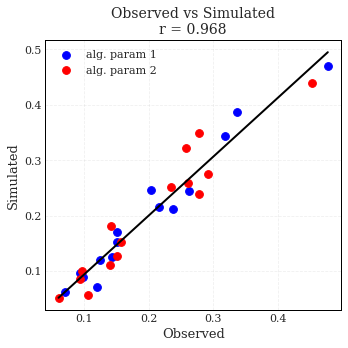

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Pearson correlation
r, p = pearsonr(OBS, SIM)

print(f"Pearson r = {r:.4f}")
print(f"p-value = {p:.4e}")

# Split data in half
mid = len(OBS) // 2

OBS_1 = OBS[:mid]
SIM_1 = SIM[:mid]

OBS_2 = OBS[mid:]
SIM_2 = SIM[mid:]

# Scatter plot
plt.figure(figsize=(5,5))

# First half: blue
plt.scatter(
    OBS_1,
    SIM_1,
    s=60,
    color='blue',
    label='alg. param 1'
)

# Second half: red
plt.scatter(
    OBS_2,
    SIM_2,
    s=60,
    color='red',
    label='alg. param 2'
)

# Linear fit over all points
coef = np.polyfit(OBS, SIM, 1)
poly1d_fn = np.poly1d(coef)

x = np.linspace(min(OBS), max(OBS), 100)

plt.plot(x, poly1d_fn(x), linewidth=2, color='black')

# Labels
plt.xlabel("Observed")
plt.ylabel("Simulated")
plt.title(f"Observed vs Simulated\nr = {r:.3f}")

# Legend
plt.legend()

plt.tight_layout()
plt.show()

# Comparison with simulation

Partition -1
[[-1.47086854 -1.00526749  1.965139    0.04252902  0.68809864]
 [ 1.44792748  0.98958839 -1.93448883 -0.0418657  -0.67736641]]
p-value: 2.3666333312382254e-18
[[-1.00767594 -1.07835373  1.10625358  0.59103337  0.75650858]
 [ 1.00845558  1.07918804 -1.10710948 -0.59149065 -0.75709389]]
p-value: 2.3666333312382254e-18
Partition 0
[[ 0.20426198 -0.16245136  0.30701825 -0.64003727  0.04456689]
 [-0.20261335  0.16114019 -0.30454026  0.63487143 -0.04420718]]
p-value: 2.3666333312382254e-18
[[-0.22545372 -0.01159583  0.37657654 -0.17934315 -0.30023136]
 [ 0.22585311  0.01161637 -0.37724364  0.17966085  0.30076322]]
p-value: 2.3666333312382254e-18
Partition 1
[[ 0.56547687  0.11330046  1.44058304 -0.55046002 -1.56234759]
 [-0.58334843 -0.11688125 -1.48611182  0.56785698  1.61172465]]
p-value: 2.3666333312382254e-18
[[ 0.76640632  0.61558701  2.15124035 -1.05893028 -2.01770067]
 [-0.76640632 -0.61558701 -2.15124035  1.05893028  2.01770067]]
p-value: 2.3666333312382254e-18


C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\1476795589.py:81: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


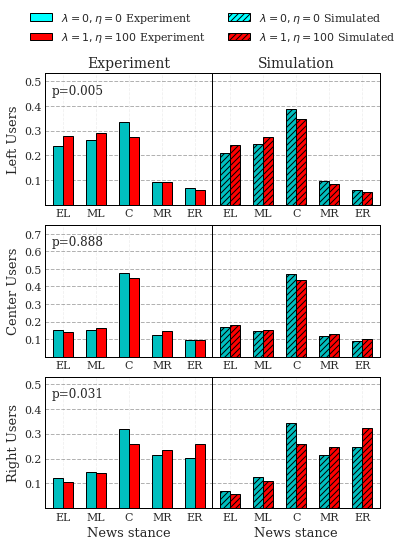

In [64]:
plt.figure(figsize=(6,8))

YLIM_CENT=(0,0.53)
YLIM_LEAN=(0,0.75)

partition2text={
    -1:'Left',
    0:'Center',
    1:'Right'
}

def click_count_to_click_list(cc):
    cl=[]
    for i, v in enumerate(cc):
        for _ in range(v):
            cl.append(i-2)
    return cl

for partition in [-1,0,1]:
    plt.subplot(3,2,1+(partition+1)*2)
    print(f"Partition {partition}")
    pval=chi2_test(P2EV[1][P2EV[1]['user_partition']==partition]['news_stance'].tolist(),
#               RESULTS[RESULTS['partition_user']==partition]['stance_text_true'].tolist(),
              P2EV[2][P2EV[2]['user_partition']==partition]['news_stance'].tolist(),
#               title_prefix=f'{partition2text[partition]} Users (Experiment)',
                return_pval=True,
              title_p_value=False,
             )
#     plt.ylim(0,0.52)
#     if partition==-1:
    plt.ylabel(f'{partition2text[partition]} Users')#\nProportion of clicks')
    # >>> Add text with partition value (top-left corner)
    plt.text(
        0.04, 0.92,          # position (x, y) in axes coordinates
        f"p={pval:.3f}",   # text
        transform=plt.gca().transAxes,  # use axes-relative coords
        ha='left', va='top',            # alignment
        fontsize=12, #fontweight='bold'  # style
    )
    
        
    plt.subplot(3,2,2+(partition+1)*2)
    chi2_test(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[1][partition].tolist()),
#               RESULTS[RESULTS['partition_user']==partition]['stance_text_true'].tolist(),
              click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[2][partition].tolist()),
#               title_prefix=f'{partition2text[partition]} Users (Simulation)', 
              title_p_value=False,
              hatches=('////','////')
             )

        
        
        


for p in range(1,6+1):
    plt.subplot(3,2,p)
    ax = plt.gca()
    if p in [3,4]:
        plt.ylim(YLIM_LEAN[0],YLIM_LEAN[1])
    else:
        plt.ylim(YLIM_CENT[0],YLIM_CENT[1])
    if p<=4:
        plt.xlabel('')
#         plt.tick_params(axis='x', which='both', labelleft=False)

#     if p%2==0:
#         plt.title('')
#     if p==1:
#         plt.ylabel("Experiment")
#     if p==4:
#         plt.ylabel("Simulated")

    
    ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    if p not in [1,3,5]:
        plt.tick_params(axis='y', which='both', labelleft=False)
    else:
        labels = ["" if val == 0 else f"{val:.1f}" for val in ax.get_yticks()]
        ax.set_yticklabels(labels)
        
    if p not in [5,6]:
#         plt.xticks([])
        pass


legend_patches = [
    mpatches.Patch(facecolor="cyan", label="$\lambda=0, \eta=0$ Experiment"),
    mpatches.Patch(facecolor="red",  label="$\lambda=1, \eta=100$ Experiment"),
    mpatches.Patch(facecolor="cyan", hatch="////",  label="$\lambda=0, \eta=0$ Simulated"),
    mpatches.Patch(facecolor="red", hatch="////", label="$\lambda=1, \eta=100$ Simulated"),
]
#Manual legend above plots
plt.subplot(3,2,1)
plt.legend(
    handles=legend_patches,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(1, 1.55),
    frameon=False
)
plt.subplot(3,2,1)
plt.title("Experiment")
plt.subplot(3,2,2)
plt.title("Simulation")

plt.subplots_adjust(hspace=0.15, wspace=0.0) 
plt.savefig('click_partitionwise_col.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/click_partitionwise_col.pdf', bbox_inches='tight')
# # plt.savefig('../Figures/png/click_partitionwise_col.png', bbox_inches='tight')

# Change ratios

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\1709867793.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


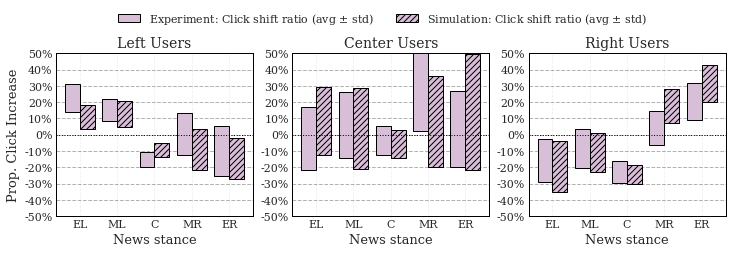

In [66]:
plt.figure(figsize=(12,3))
for p in [-1,0,1]:
    cc_1_count=click_list_to_count(P2EV[1][P2EV[1]['user_partition']==p]['news_stance'].tolist())
    cc_2_count=click_list_to_count(P2EV[2][P2EV[2]['user_partition']==p]['news_stance'].tolist())
    cc_1=[cc_1_count[s] for s in POSSIBLE_STANCES]
    cc_2=[cc_2_count[s] for s in POSSIBLE_STANCES]
    cc_1=np.array(cc_1)/sum(cc_1)
    cc_2=np.array(cc_2)/sum(cc_2)
    
    cc_s_1_count=click_list_to_count(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[1][p].tolist()))
    cc_s_2_count=click_list_to_count(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[2][p].tolist()))
    cc_s_1=[cc_s_1_count[s] for s in POSSIBLE_STANCES]
    cc_s_2=[cc_s_2_count[s] for s in POSSIBLE_STANCES]
    cc_s_1=np.array(cc_s_1)/sum(cc_s_1)
    cc_s_2=np.array(cc_s_2)/sum(cc_s_2)
    
    cc_1_boot=boostrap_click_list(P2EV[1][P2EV[1]['user_partition']==p]['news_stance'].tolist(), return_all=True)
    cc_2_boot=boostrap_click_list(P2EV[2][P2EV[2]['user_partition']==p]['news_stance'].tolist(), return_all=True)
    cc_avg=(cc_2_boot/cc_1_boot).mean(axis=0)-1
    cc_std=(cc_2_boot/cc_1_boot).std(axis=0)
    
    cc_1_s_boot=boostrap_click_list(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[1][p].tolist()), return_all=True)
    cc_2_s_boot=boostrap_click_list(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[2][p].tolist()), return_all=True)
    cc_s_avg=(cc_2_s_boot/cc_1_s_boot).mean(axis=0)-1
    cc_s_std=(cc_2_s_boot/cc_1_s_boot).std(axis=0)
    
    plt.subplot(1,3,p+2)
#     plt.bar(np.array([-2,-1,0,1,2])-0.2, cc_2/cc_1-1, width=0.4, color='thistle')
#     plt.bar(np.array([-2,-1,0,1,2])+0.2, cc_s_2/cc_s_1-1, width=0.4, color='thistle', hatch='////')
#     plt.bar(np.array([-2,-1,0,1,2])-0.2, cc_avg, yerr=cc_std, width=0.4, color='thistle',
#            capsize=2, error_kw={'capthick': 2, 'elinewidth': 1})
#     plt.bar(np.array([-2,-1,0,1,2])+0.2, cc_s_avg, yerr=cc_s_std, width=0.4, color='thistle', hatch='////',
#            capsize=2, error_kw={'capthick': 1, 'elinewidth': 1})
    plt.bar(np.array([-2,-1,0,1,2])-0.2, 2*cc_std, bottom=cc_avg-cc_std, width=0.4, color='thistle',
           capsize=2, error_kw={'capthick': 2, 'elinewidth': 1})
    plt.bar(np.array([-2,-1,0,1,2])+0.2, 2*cc_s_std, bottom=cc_s_avg-cc_s_std, width=0.4, color='thistle', hatch='////',
           capsize=2, error_kw={'capthick': 1, 'elinewidth': 1})
    plt.axhline(0, color='k', linewidth=1, linestyle=':')
    plt.ylim(-0.5,0.5)
    plt.title(f"{partition2text[p]} Users")
    plt.xticks(POSSIBLE_STANCES, ['EL','ML','C','MR','ER'])
    plt.xlabel("News stance")
    ax=plt.gca()
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    if p==-1:
        plt.ylabel("Prop. Click Increase")
    else:
#         plt.tick_params(axis='y', which='both', labelleft=False)
        pass
    labels = ["" if val == 0 else f"{val*100:.0f}%" for val in ax.get_yticks()]
    ax.set_yticklabels(labels)
    plt.subplots_adjust(wspace=0.2) 
    ax.grid(True, axis='y', color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(facecolor="thistle", label="Experiment: Click shift ratio (avg $\pm$ std)"),
    mpatches.Patch(facecolor="thistle", hatch='////', label="Simulation: Click shift ratio (avg $\pm$ std)"),
]
#Manual legend above plots
plt.subplot(1,3,2)
plt.legend(
    handles=legend_patches,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.46, 1.32),
    frameon=False
)
plt.savefig('click_shift_ratio.pdf', bbox_inches='tight')
# plt.savefig('../Figures/click_shift_ratio.pdf', bbox_inches='tight')
# plt.savefig('../Figures/png/click_shift_ratio.png', bbox_inches='tight')

# Column by column comparison

In [67]:
# example data
EXPvEXP={p:{s:'ph' for s in [-2,-1,0,1,2]} for p in [-1,0,1]}
EXPvSIM={p:{s:'ph' for s in [-2,-1,0,1,2]} for p in [-1,0,1]}

for case in ['e','s']:
    for p in [-1,0,1]:
        for s in range(5):
            cc_1_boot=boostrap_click_list(P2EV[1][P2EV[1]['user_partition']==p]['news_stance'].tolist(), n_samples=10, return_all=True)
            cc_2_boot=boostrap_click_list(P2EV[2][P2EV[2]['user_partition']==p]['news_stance'].tolist(), n_samples=10, return_all=True)

            cc_1_s_boot=boostrap_click_list(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[1][p].tolist()), n_samples=10, return_all=True)
            cc_2_s_boot=boostrap_click_list(click_count_to_click_list(CLICK_PARTITIONWISE_SIMULATED[2][p].tolist()), n_samples=10, return_all=True)

            cc_1_norm=cc_1_boot * (1 / cc_1_boot.sum(axis=1)[:, None])
            cc_2_norm=cc_2_boot * (1 / cc_2_boot.sum(axis=1)[:, None])

            cc_1_s_norm=cc_1_s_boot * (1 / cc_1_s_boot.sum(axis=1)[:, None])
            cc_2_s_norm=cc_2_s_boot * (1 / cc_2_s_boot.sum(axis=1)[:, None])


            list1 = [v[s] for v in cc_1_norm]
        #     
            if case=='e':
                list2 = [v[s] for v in cc_2_norm]
            elif case=='s':
                list2 = [v[s] for v in cc_1_s_norm]

            print("comparing against",case,"partition",p," stance", s-2,'-'*50)
#             # Check normality (optional)
#             print(stats.shapiro(list1))
#             print(stats.shapiro(list2))

#             # If independent samples, test means
#             t_stat, p_val = stats.ttest_ind(list1, list2)  # independent t-test
#             print("t-test:", t_stat, p_val)

            # Non-parametric alternative
            u_stat, p_val = stats.mannwhitneyu(list1, list2)
            print("Mann-Whitney U:", u_stat, p_val)
            
            if case=='e':
                EXPvEXP[p][s-2]=p_val
            elif case=='s':
                EXPvSIM[p][s-2]=p_val

#             # Compare full distributions
#             ks_stat, p_val = stats.ks_2samp(list1, list2)
#             print("KS test:", ks_stat, p_val)
#             print()

comparing against e partition -1  stance -2 --------------------------------------------------
Mann-Whitney U: 0.0 0.000181651146091465
comparing against e partition -1  stance -1 --------------------------------------------------
Mann-Whitney U: 0.0 0.000181651146091465
comparing against e partition -1  stance 0 --------------------------------------------------
Mann-Whitney U: 100.0 0.0001806347208075351
comparing against e partition -1  stance 1 --------------------------------------------------
Mann-Whitney U: 52.0 0.9096880762234906
comparing against e partition -1  stance 2 --------------------------------------------------
Mann-Whitney U: 81.0 0.0211339281291611
comparing against e partition 0  stance -2 --------------------------------------------------
Mann-Whitney U: 73.0 0.08885290847904963
comparing against e partition 0  stance -1 --------------------------------------------------
Mann-Whitney U: 28.0 0.10371940175625873
comparing against e partition 0  stance 0 ----------

In [68]:
pd.DataFrame(EXPvSIM).T

,-2,-1,0,1,2
-1,0.001699,0.063922,0.000182,0.307308,0.037635
0,0.025359,0.969839,0.849884,0.426135,0.210225
1,0.000180,0.009056,0.002807,0.017216,0.001004


In [69]:
pd.DataFrame(EXPvEXP).T

,-2,-1,0,1,2
-1,0.000182,0.000182,0.000181,0.909688,0.021134
0,0.088853,0.103719,0.013911,0.000178,0.102677
1,0.004571,0.677356,0.000179,0.044832,0.000179


# Ranking analysis

In [70]:
POPULARITIES=pd.read_csv(f'../CODE_EXPERIMENT/my_survey_static/popularities.csv')

In [71]:
ranks=[]
for s in SEEDS:
    for p in [-1,0,1]:
        s_pop=POPULARITIES[POPULARITIES['seed']==int(s)][POPULARITIES['partition']==p]
        ranks+=s_pop['popularity'].rank(ascending=False).tolist()
POPULARITIES['rank']=ranks

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2307016484.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  s_pop=POPULARITIES[POPULARITIES['seed']==int(s)][POPULARITIES['partition']==p]
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2307016484.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  s_pop=POPULARITIES[POPULARITIES['seed']==int(s)][POPULARITIES['partition']==p]
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2307016484.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  s_pop=POPULARITIES[POPULARITIES['seed']==int(s)][POPULARITIES['partition']==p]
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2307016484.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  s_pop=POPULARITIES[POPULARITIES['seed']==int(s)][POPULARITIES['partition']==p]
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\2307016484.py:4: UserWarning: Boolean Series key 

In [72]:
def num2stance(num):
    if num<2: return -2
    if num<4: return -1
    if num<6: return 0
    if num<8: return 1
    return 2

POPULARITIES['news_stance']=POPULARITIES['num_news'].map(num2stance)

POPULARITIES['parametrization+partition']=POPULARITIES['seed'].map(lambda x: int(str(x)[0])-1)
POPULARITIES['parametrization+partition']*=(POPULARITIES['partition']+2)


In [73]:
SP2AVGRANK={s:{p:{v:'ph' for v in [-2,-1,0,1,2]} for p in [-1,0,1]}for s in SEEDS}
SP2STDRANK={s:{p:{v:'ph' for v in [-2,-1,0,1,2]} for p in [-1,0,1]}for s in SEEDS}


for s in SEEDS:
    for p in [-1,0,1]:
        for v in [-2,-1,0,1,2]:
            SP2AVGRANK[s][p][v]=\
            POPULARITIES[POPULARITIES['seed']==int(s)]\
            [POPULARITIES['partition']==p]\
            [POPULARITIES['news_stance']==v]\
            ['rank'].mean()

C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\487138004.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  POPULARITIES[POPULARITIES['seed']==int(s)]\
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\487138004.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  POPULARITIES[POPULARITIES['seed']==int(s)]\
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\487138004.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  POPULARITIES[POPULARITIES['seed']==int(s)]\
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\487138004.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  POPULARITIES[POPULARITIES['seed']==int(s)]\
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\487138004.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  POPULARITIES[POPULARITIES['seed']==int(s)]\
C:\Users\Utente\AppData\Local\Temp\ipykernel_22080\4871

In [74]:
PP2AVGRANK={s:{p:{v:'ph' for v in [-2,-1,0,1,2]} for p in [-1,0,1]}for s in [1,2]}
PP2STDRANK={s:{p:{v:'ph' for v in [-2,-1,0,1,2]} for p in [-1,0,1]}for s in [1,2]}

for p in [-1,0,1]:
    for v in [-2,-1,0,1,2]:
        for par in [1,2]:
            s_avgrank=[]
            for s in SEEDS:
                if s.startswith(str(par)):
                    s_avgrank.append(SP2AVGRANK[s][p][v])
            PP2AVGRANK[par][p][v]=np.mean(s_avgrank)
            print(s_avgrank)
            PP2STDRANK[par][p][v]=np.std(s_avgrank)

[8.5, 9.5, 7.5, 4.0, 5.5, 6.0, 5.5, 5.5, 5.5, 5.5, 5.5, 4.0]
[4.5, 6.0, 4.0, 2.5, 6.5, 3.5, 4.5, 2.0, 5.5, 4.0, 2.5, 3.5]
[3.5, 5.0, 4.0, 4.5, 5.5, 4.5, 5.5, 2.5, 5.0, 6.5, 5.5, 4.5]
[3.0, 1.5, 3.5, 3.5, 4.5, 2.0, 3.5, 3.0, 2.5, 3.5, 6.0, 3.0]
[2.5, 2.0, 2.0, 3.0, 1.5, 2.0, 3.0, 4.5, 2.0, 1.5, 2.0, 2.5]
[6.0, 4.0, 3.5, 4.5, 2.5, 5.0, 3.5, 5.5, 2.5, 3.0, 2.5, 4.0]
[4.5, 4.5, 6.5, 7.5, 5.5, 9.5, 6.0, 6.5, 7.5, 6.5, 7.5, 8.5]
[4.5, 6.5, 7.5, 9.5, 4.5, 9.5, 8.0, 7.5, 8.0, 8.5, 9.5, 7.5]
[8.5, 6.5, 7.5, 8.5, 9.5, 5.5, 7.5, 8.5, 7.5, 7.5, 7.0, 8.0]
[9.5, 9.5, 9.0, 7.5, 9.5, 7.5, 8.0, 9.5, 9.0, 8.5, 7.0, 9.5]
[8.5, 9.5, 7.5, 4.0, 5.5, 6.0, 5.5, 5.5, 5.5, 5.5, 5.5, 4.0]
[4.0, 7.0, 6.0, 6.0, 6.5, 5.5, 6.0, 3.0, 7.0, 6.5, 6.5, 7.0]
[3.5, 5.0, 4.0, 4.5, 5.5, 4.5, 5.5, 2.5, 5.0, 6.5, 5.5, 4.5]
[7.0, 7.5, 3.5, 9.0, 4.5, 6.5, 5.0, 6.5, 4.5, 6.0, 9.0, 4.5]
[2.5, 2.0, 2.0, 3.0, 1.5, 2.0, 3.0, 4.5, 2.0, 1.5, 2.0, 2.5]
[4.0, 2.0, 6.0, 4.0, 2.0, 4.0, 2.0, 4.5, 2.5, 1.5, 3.5, 1.5]
[4.5, 4.5, 6.5, 7.5, 5.5

In [75]:
PP2AVGRANK

{1: {-1: {-2: 6.041666666666667,
   -1: 4.708333333333333,
   0: 2.375,
   1: 6.708333333333333,
   2: 7.666666666666667},
  0: {-2: 6.041666666666667,
   -1: 4.708333333333333,
   0: 2.375,
   1: 6.708333333333333,
   2: 7.666666666666667},
  1: {-2: 6.041666666666667,
   -1: 4.708333333333333,
   0: 2.375,
   1: 6.708333333333333,
   2: 7.666666666666667}},
 2: {-1: {-2: 4.083333333333333,
   -1: 3.2916666666666665,
   0: 3.875,
   1: 7.583333333333333,
   2: 8.666666666666666},
  0: {-2: 5.916666666666667,
   -1: 6.125,
   0: 3.125,
   1: 5.708333333333333,
   2: 6.625},
  1: {-2: 7.708333333333333,
   -1: 7.041666666666667,
   0: 5.458333333333333,
   1: 4.041666666666667,
   2: 3.25}}}

In [76]:
AVGRANK_DISPLAY={'$\eta=0, \lambda=0$':{v: str(PP2AVGRANK[1][0][v].round(1))+'+-'+str(PP2STDRANK[1][0][v].round(1)) for v in [-2,-1,0,1,2]},
                 '$Left \qquad \eta=100, \lambda=1$':{v: str(PP2AVGRANK[2][-1][v].round(1))+'+-'+str(PP2STDRANK[2][-1][v].round(1)) for v in [-2,-1,0,1,2]},
                 '$Center \qquad \eta=100, \lambda=1$':{v: str(PP2AVGRANK[2][0][v].round(1))+'+-'+str(PP2STDRANK[2][0][v].round(1)) for v in [-2,-1,0,1,2]},
                 '$Right \qquad \eta=100, \lambda=1$':{v: str(PP2AVGRANK[2][1][v].round(1))+'+-'+str(PP2STDRANK[2][1][v].round(1)) for v in [-2,-1,0,1,2]},
                }

In [77]:
AVGRANK_DISPLAY_ALPHA=pd.DataFrame(AVGRANK_DISPLAY).T.round(2)

In [78]:
AVGRANK_DISPLAY_ALPHA.columns=['Ext. Left', 'Mod. Left', 'Center', 'Mod. Right', 'Ext. Right']
AVGRANK_DISPLAY_ALPHA

,Ext. Left,Mod. Left,Center,Mod. Right,Ext. Right
"$\eta=0, \lambda=0$",6.0+-1.6,4.7+-1.0,2.4+-0.8,6.7+-1.4,7.7+-1.0
"$Left \qquad \eta=100, \lambda=1$",4.1+-1.4,3.3+-1.1,3.9+-1.1,7.6+-1.6,8.7+-0.9
"$Center \qquad \eta=100, \lambda=1$",5.9+-1.2,6.1+-1.7,3.1+-1.4,5.7+-1.8,6.6+-1.9
"$Right \qquad \eta=100, \lambda=1$",7.7+-1.2,7.0+-1.6,5.5+-1.3,4.0+-1.1,3.2+-0.9
